# 🟡 Function F3 — Week 6 | Black-Box Optimisation
### Prepared by Mike Kennelly | BBO Capstone Project | Adaptive Model + GP/EI Pipeline

---

## 📌 F3 Function Profile

| Property | Value |
|----------|-------|
| **Dimensions** | 3D (X1, X2, X3) |
| **Search space** | [0, 1]³ |
| **Samples at W6** | 20 |
| **n/p ratio** | 6.7 (adequate) |
| **All-time best** | -0.01358 @ idx 17 — point [0.966, 0.518, 0.403] |
| **W5 score** | -0.0590 (below best but above most evals) |
| **Y range** | [-0.399, -0.014] — all values negative |
| **Objective** | MAXIMISE ⬆️ — closest to zero wins |

---

## 🧭 Week 6 Strategy: EXPLOIT CAREFULLY

**F3's entire output range is negative — the function maximum is somewhere close to zero, and we are hunting it.** The all-time best of -0.01358 was achieved at idx 17 with point [0.966, 0.518, 0.403]. This is a strong signal: X1 wants to be near 1.0, while X2 and X3 sit in the mid-range [0.4–0.5].

The per-dimension acquisition curves (Step 11) will be especially diagnostic for F3. In 3D, it is plausible that the function has a sharp ridge along X1 (near 1.0) and a flatter plateau in X2/X3. We exploit the known best point but keep enough exploration to test whether X1 values above 0.966 yield further improvement.

### Rationale

Module 17's question on **depth, computational cost and overfitting** maps directly onto F3's challenge. Training deep CNNs involves the risk of overfitting to training data, especially when the dataset is small relative to model complexity. F3 has only 20 samples in 3D — the GP may overfit to the noisy negative values and produce a poor surrogate. The careful exploit strategy (EXPLOIT_RATIO=0.75, not 0.85) acknowledges this risk by retaining 25% exploration as insurance.

The **convolution parallel** is also relevant: the Matern 5/2 GP kernel slides across the 3D input space looking for the same similarity structure regardless of where it appears — exactly like a convolutional filter. The fact that our best point has X1≈0.966 suggests the kernel's learned length scale in the X1 dimension is short (sensitive to small changes near 1.0). The per-dimension EI curves will confirm whether this is true.

### Key Parameter Changes vs Default

| Parameter | Default | F3 W6 Value | Reason |
|-----------|---------|-------------|--------|
| `EXPLOIT_RATIO` | 0.80 | **0.75** | Slightly reduced — 3D landscape not fully mapped, retain 25% exploration |
| `EXPLOIT_SIGMA` | 0.05 | **0.04** | Modest tightening — best point [0.966, 0.518, 0.403] well-identified |
| `UCB_KAPPA` | 2.0 | **2.0** | Standard — negative but improving trajectory gives reasonable EI signal |
| `GP_RESTARTS` | 5 | **8** | Extra restarts — 3D landscape benefits from more thorough kernel fitting |

### What to Watch

- **X1 near 1.0**: Best point has X1=0.966. Does EI peak at 0.97–0.99? That tells us X1 wants to push further toward the boundary.
- **All negative outputs**: The GP must fit a function that is everywhere negative. Check GP R² — if it is below 0.5, the surrogate is unreliable and we should trust UCB over EI.
- **W5 score was -0.059**: Below the best of -0.014. This is a recovery situation — W5 moved us further from the peak, making W6 more important.

### Module 17 Connection

> *"Training CNNs involves balancing depth, computational cost and overfitting risks. Did you face similar trade-offs in BBO?"*

F3 is the clearest example of the **overfitting risk** in our BBO pipeline. With 20 samples in 3D, asking a GP to fit the landscape with 8 restarts and a flexible Matern kernel is borderline ambitious. The n/p ratio of 6.7 is adequate but not comfortable. This is why we keep EXPLOIT_RATIO at 0.75 rather than 0.85 — the equivalent of adding dropout to a network that is slightly too deep for the dataset size. We are regularising our exploitation.

> *"Convolutions, pooling, activations, loss functions — which changed your thinking?"*

The **loss function gap** is critical for F3. Our EI formula computes improvement relative to y_best = -0.014. But the true function maximum might be -0.001 or even 0.0 — we don't know. EI is optimising a proxy: 'improve on -0.014.' If the true maximum is much higher, we may converge to a local optimum. The per-dimension curves in Step 11 are our check: if UCB and EI peaks diverge significantly in any dimension, it signals the proxy is unreliable.

---

## 🗺️ Full Pipeline
```
STEP 0 : Configuration — F3 EXPLOIT CAREFULLY settings
STEP 1 : Imports
STEP 2 : Load F3 W6 Data  (20 samples, 3D)
STEP 3 : Visualise F3 History  (all negative — watch for upward trajectory)
STEP 4 : Binary Labels  (top 30% — 6 positives, all near zero)
STEP 5 : Train 7 Models on F3
STEP 6 : Visualise Model Predictions on F3
STEP 7 : CV Comparison — expect NN or SVM to separate near-zero cluster
STEP 8 : Candidates  (75% exploit around [0.966, 0.518, 0.403], 25% explore)
STEP 9 : GP Fit  (check R² — fitting all-negative landscape)
STEP 10: EI & UCB  (both computed relative to best = -0.014)
STEP 11: Per-Dim Curves  (watch X1 — does it peak near 1.0?)
STEP 12: Acquisition Surface  (top 2 sensitive dims)
STEP 13: Top Candidates & Dashboard
STEP 14: Final Formatted Submission
STEP 15: Save F3 W6 Hyperparameter Record
```
---

---
## ⚙️ STEP 0 — F3 Configuration & Hyperparameter Documentation

### 🔧 F3-Specific Settings (Week 6 EXPLOIT CAREFULLY Strategy)

F3 outputs are entirely negative. We are maximising toward zero. The best point [0.966, 0.518, 0.403] at -0.014 is promising but W5 regressed to -0.059. Careful exploitation with 25% exploration handles the risk that our GP overfits the noisy negative landscape.

---

### 📚 F3 Hyperparameter Reference

| Parameter | F3 W6 Value | Purpose | Rationale for F3 |
|-----------|-------------|---------|------------------|
| `TOP_PERCENTILE` | **30%** | Top X% labelled class 1 | 20 samples → 6 positives. The top 6 values (near zero) are well-separated from the rest of the negative cluster. |
| `N_CANDIDATES` | **10,000** | Candidate pool size | Full pool. 3D space is larger — 10k provides adequate density for GP pre-filtering. |
| `EXPLOIT_RATIO` | **0.75** | Fraction near best (slightly reduced) | 3D not fully mapped; 25% exploration guards against overfitting to a local optimum near [0.966, 0.518, 0.403]. |
| `EXPLOIT_SIGMA` | **0.04** | Gaussian sigma (modestly tightened) | Best point well-identified — modest tightening. X1 near boundary (0.966) so sigma must not exceed the [0,1] clip. |
| `UCB_KAPPA` | **2.0** | UCB exploration bonus | Standard. Negative-but-improving trajectory gives usable EI signal. |
| `EI_XI` | **0.01** | Exploration jitter | Standard. EI = max(0, mu - (-0.014) - 0.01). |
| `GP_RESTARTS` | **8** | GP restarts (raised) | 3D landscape benefits from thorough kernel hyperparameter search. Matern length scales may differ significantly across X1, X2, X3. |
| `FILTER_PERCENTILE` | **50%** | Candidate filter | Standard. |
| `RANDOM_SEED` | **42** | Reproducibility | Fixed. |

### ⚠️ Parameters changed from default: EXPLOIT_RATIO (0.80→0.75), EXPLOIT_SIGMA (0.05→0.04), GP_RESTARTS (5→8)

In [1]:
# ╔══════════════════════════════════════════════════════════════╗
# ║   F3 WEEK 6 CONFIGURATION — EXPLOIT CAREFULLY               ║
# ║   Mike | BBO Capstone | Week 6                              ║
# ╚══════════════════════════════════════════════════════════════╝
FUNCTION_ID  = 'F3'
WEEK         = 6
INPUT_FILE   = 'f3_w6_inputs.npy'
OUTPUT_FILE  = 'f3_w6_outputs.npy'

# ── F3 Hyperparameters (EXPLOIT CAREFULLY — all-negative landscape) ───────
TOP_PERCENTILE    = 30      # 6 positives — near-zero cluster well-separated
N_CANDIDATES      = 10000   # Full pool — 3D space needs dense coverage
EXPLOIT_RATIO     = 0.75    # ⚠️ SLIGHTLY REDUCED: 25% exploration for 3D insurance
EXPLOIT_SIGMA     = 0.04    # ⚠️ MODEST TIGHTEN: best point well-identified at [0.966, 0.518, 0.403]
UCB_KAPPA         = 2.0     # Standard — improving trajectory gives usable EI signal
EI_XI             = 0.01    # Standard
GP_RESTARTS       = 8       # ⚠️ RAISED: 3D landscape benefits from thorough kernel search
FILTER_PERCENTILE = 50      # Standard
RANDOM_SEED       = 42
MAXIMIZE          = True    # ⬆️ ALWAYS True — closest to zero wins in F3

# ── Neural Network architectures (3D, 20 samples — medium may generalise) ─
NN_SMALL  = (16, 8)          # Lightweight — may lack capacity for 3D
NN_MEDIUM = (64, 32)         # Likely winner — balanced for 20 samples
NN_LARGE  = (128, 64, 32)    # Risk of overfitting on 20 samples in 3D

print('╔' + '═'*62 + '╗')
print(f'║  F3 WEEK {WEEK} — 3D FUNCTION — EXPLOIT CAREFULLY             ║')
print(f'║  Mike | BBO Capstone | All-negative landscape              ║')
print('╠' + '═'*62 + '╣')
print(f'║  Input  : {INPUT_FILE:<53}║')
print(f'║  Output : {OUTPUT_FILE:<53}║')
print(f'║  Goal   : MAXIMIZE -- closest to ZERO wins                 ║')
print('╠' + '═'*62 + '╣')
print(f'║  Strategy: EXPLOIT CAREFULLY  |  ratio=0.75  sigma=0.04   ║')
print(f'║  Target  : [0.966, 0.518, 0.403]  best=-0.01358           ║')
print(f'║  Note    : W5 regressed (-0.059) — recovery mode W6       ║')
print('╚' + '═'*62 + '╝')

╔══════════════════════════════════════════════════════════════╗
║  F3 WEEK 6 — 3D FUNCTION — EXPLOIT CAREFULLY             ║
║  Mike | BBO Capstone | All-negative landscape              ║
╠══════════════════════════════════════════════════════════════╣
║  Input  : f3_w6_inputs.npy                                     ║
║  Output : f3_w6_outputs.npy                                    ║
║  Goal   : MAXIMIZE -- closest to ZERO wins                 ║
╠══════════════════════════════════════════════════════════════╣
║  Strategy: EXPLOIT CAREFULLY  |  ratio=0.75  sigma=0.04   ║
║  Target  : [0.966, 0.518, 0.403]  best=-0.01358           ║
║  Note    : W5 regressed (-0.059) — recovery mode W6       ║
╚══════════════════════════════════════════════════════════════╝


---
## 📦 STEP 1 — Imports

All libraries loaded here. **scikit-learn** provides classifiers, GP, and CV utilities. **scipy.stats** gives us the normal CDF/PDF for the EI formula. **matplotlib** handles all visualisations.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
import warnings
warnings.filterwarnings('ignore')

from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, ConstantKernel as C
from scipy.stats import norm

np.random.seed(RANDOM_SEED)
plt.rcParams.update({'figure.dpi': 110, 'font.size': 10,
                     'axes.titlesize': 11, 'axes.labelsize': 10})
print('✅ All libraries loaded')

✅ All libraries loaded


---
## 📥 STEP 2 — Load Data

We load all historical evaluations. Key statistics to note:
- **n/p ratio** (samples ÷ dims): below 5 = data-sparse (GP may struggle); above 10 = comfortable
- **Best point** is found via `argmax` (MAXIMIZATION) — this becomes the centre of exploitation
- **Gap from best to latest** tells us if we're in recovery mode or pushing new ground

In [3]:
X_train = np.load(INPUT_FILE)
y_train = np.load(OUTPUT_FILE)
n_samples, n_dims = X_train.shape

best_idx   = np.argmax(y_train)   # ARGMAX — maximization
best_value = y_train[best_idx]
best_point = X_train[best_idx]
latest_val = y_train[-1]

print('═'*65)
print(f'  DATA — {FUNCTION_ID}  Week {WEEK}')
print('═'*65)
print(f'  Samples      : {n_samples}')
print(f'  Dimensions   : {n_dims}D')
print(f'  n/p ratio    : {n_samples/n_dims:.2f}  {"✅ comfortable" if n_samples/n_dims>=5 else "⚠️ sparse"}')
print(f'  Y range      : [{y_train.min():.6f},  {y_train.max():.6f}]')
print(f'  Y mean ± std : {y_train.mean():.6f} ± {y_train.std():.6f}')
print(f'  🏆 BEST      : {best_value:.6f}  @ index {best_idx}')
print(f'  📍 Location  : {best_point}')
print(f'  📅 Latest    : {latest_val:.6f}  (Week {WEEK-1})')
print(f'  Gap          : {best_value - latest_val:+.6f}  {"(recovering)" if latest_val < best_value else "(at best)"}')

# Compute percentile thresholds for labelling
threshold = np.percentile(y_train, 100 - TOP_PERCENTILE)
n_pos = int(np.sum(y_train >= threshold))
n_cv_folds = max(2, min(5, int(min(n_pos, n_samples - n_pos) / 2)))
print(f'\n  Label threshold (top {TOP_PERCENTILE}%): {threshold:.6f}  ({n_pos} positives)')
print(f'  CV folds chosen: {n_cv_folds}')

scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X_train)
print('  ✅ Features standardised')

═════════════════════════════════════════════════════════════════
  DATA — F3  Week 6
═════════════════════════════════════════════════════════════════
  Samples      : 20
  Dimensions   : 3D
  n/p ratio    : 6.67  ✅ comfortable
  Y range      : [-0.398926,  -0.013577]
  Y mean ± std : -0.097768 ± 0.078227
  🏆 BEST      : -0.013577  @ index 17
  📍 Location  : [0.965995 0.517677 0.402788]
  📅 Latest    : -0.059003  (Week 5)
  Gap          : +0.045426  (recovering)

  Label threshold (top 30%): -0.054133  (6 positives)
  CV folds chosen: 3
  ✅ Features standardised


---
## 📊 STEP 3 — Visualise Historical Performance

Three views to understand the function landscape before building models:
1. **All evaluations vs time** — shows trajectory and whether we're trending up or down
2. **Running best** — flat line = stalled, sharp jump = breakthrough
3. **Value distribution** — colour-coded by the top-30% threshold

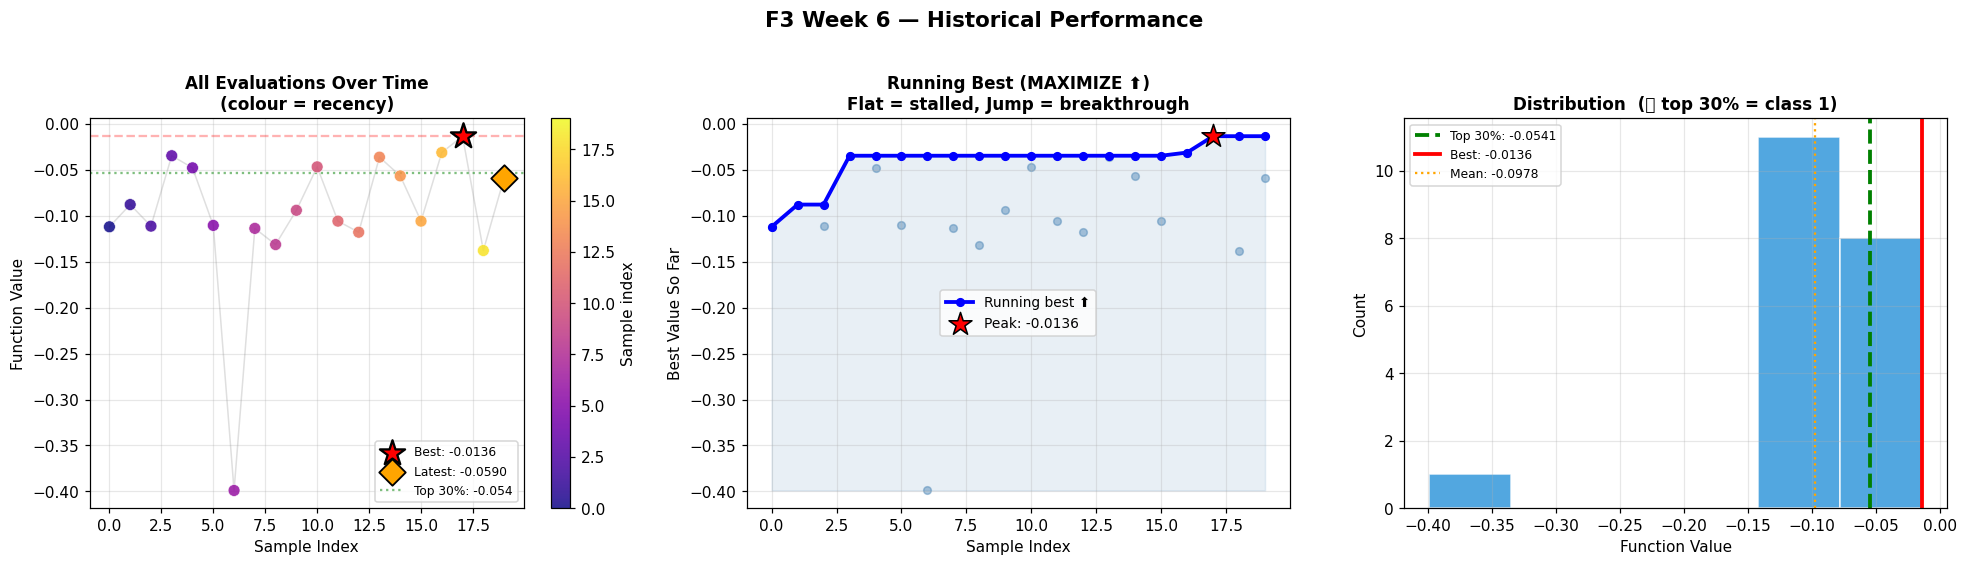

✅ Saved: F3_W6_Step3_History.png


In [4]:
indices = np.arange(n_samples)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle(f'{FUNCTION_ID} Week {WEEK} — Historical Performance', fontsize=14, fontweight='bold', y=1.02)

# Plot 1: All evaluations
ax = axes[0]
sc = ax.scatter(indices, y_train, c=indices, cmap='plasma', s=60, alpha=0.85,
                zorder=3, edgecolors='white', linewidths=0.4)
ax.plot(indices, y_train, color='gray', alpha=0.25, linewidth=1)
ax.scatter(best_idx, best_value, c='red', s=300, marker='*', zorder=6,
           edgecolors='black', linewidths=1.5, label=f'Best: {best_value:.4f}')
ax.scatter(n_samples-1, latest_val, c='orange', s=150, marker='D', zorder=5,
           edgecolors='black', linewidths=1.2, label=f'Latest: {latest_val:.4f}')
ax.axhline(best_value, color='red', linestyle='--', alpha=0.3, linewidth=1.5)
ax.axhline(threshold, color='green', linestyle=':', alpha=0.5, linewidth=1.5,
           label=f'Top {TOP_PERCENTILE}%: {threshold:.3f}')
ax.set_xlabel('Sample Index'); ax.set_ylabel('Function Value')
ax.set_title('All Evaluations Over Time\n(colour = recency)', fontweight='bold')
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)
plt.colorbar(sc, ax=ax, label='Sample index')

# Plot 2: Running best
ax = axes[1]
running_best = np.maximum.accumulate(y_train)
ax.fill_between(indices, y_train.min(), running_best, alpha=0.12, color='steelblue')
ax.plot(indices, running_best, 'b-o', markersize=5, linewidth=2.5, label='Running best ⬆️')
ax.scatter(indices, y_train, color='steelblue', s=25, alpha=0.45)
ax.scatter(best_idx, best_value, c='red', s=250, marker='*', zorder=5,
           edgecolors='black', label=f'Peak: {best_value:.4f}')
ax.set_xlabel('Sample Index'); ax.set_ylabel('Best Value So Far')
ax.set_title('Running Best (MAXIMIZE ⬆️)\nFlat = stalled, Jump = breakthrough', fontweight='bold')
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

# Plot 3: Value distribution
ax = axes[2]
n_bins = min(20, max(5, n_samples // 3))
counts, edges, patches = ax.hist(y_train, bins=n_bins, edgecolor='white', alpha=0.85)
for patch, left in zip(patches, edges[:-1]):
    patch.set_facecolor('#2ecc71' if left >= threshold else '#3498db')
ax.axvline(threshold, color='green', linewidth=2.5, linestyle='--',
           label=f'Top {TOP_PERCENTILE}%: {threshold:.4f}')
ax.axvline(best_value, color='red', linewidth=2.5, label=f'Best: {best_value:.4f}')
ax.axvline(y_train.mean(), color='orange', linewidth=1.5, linestyle=':', label=f'Mean: {y_train.mean():.4f}')
ax.set_xlabel('Function Value'); ax.set_ylabel('Count')
ax.set_title(f'Distribution  (🟢 top {TOP_PERCENTILE}% = class 1)', fontweight='bold')
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{FUNCTION_ID}_W{WEEK}_Step3_History.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'✅ Saved: {FUNCTION_ID}_W{WEEK}_Step3_History.png')

---
## 🏷️ STEP 4 — Binary Classification Labels

**Why classify?** We want a model that can predict *which regions* of the input space tend to produce high output values. This is a classification task: class 1 = "good" (top 30%), class 0 = "bad" (bottom 70%).

**MAXIMIZATION direction**: class 1 = **highest** values. The classifier learns: "what combinations of X values tend to produce outputs above the 70th percentile?"

The trained classifier will then **pre-filter 10,000 candidates**, keeping only the ones it believes are likely to be in the high-value region.

In [5]:
y_labels = (y_train >= threshold).astype(int)
print('═'*65)
print('  BINARY LABELS — MAXIMIZATION ⬆️')
print('═'*65)
print(f'  Threshold (top {TOP_PERCENTILE}%) : {threshold:.6f}')
print(f'  Class 1 (HIGH — good) : {n_pos} samples  ({100*n_pos/n_samples:.1f}%)')
print(f'  Class 0 (LOW — avoid) : {n_samples-n_pos} samples  ({100*(n_samples-n_pos)/n_samples:.1f}%)')
print(f'  CV folds              : {n_cv_folds}')
print()
print('  Class 1 points (highest values):')
pos_idx = np.where(y_labels == 1)[0]
for i in pos_idx:
    print(f'    idx={i:3d}  y={y_train[i]:.6f}  X={X_train[i]}')

═════════════════════════════════════════════════════════════════
  BINARY LABELS — MAXIMIZATION ⬆️
═════════════════════════════════════════════════════════════════
  Threshold (top 30%) : -0.054133
  Class 1 (HIGH — good) : 6 samples  (30.0%)
  Class 0 (LOW — avoid) : 14 samples  (70.0%)
  CV folds              : 3

  Class 1 points (highest values):
    idx=  3  y=-0.034835  X=[0.49258141 0.61159319 0.34017639]
    idx=  4  y=-0.048008  X=[0.13462167 0.21991724 0.45820622]
    idx= 10  y=-0.046947  X=[0.22054934 0.29782524 0.34355534]
    idx= 13  y=-0.036378  X=[0.60009728 0.72513573 0.06608864]
    idx= 16  y=-0.031352  X=[0.49777442 0.53347796 0.45205292]
    idx= 17  y=-0.013577  X=[0.965995 0.517677 0.402788]


---
## 🤖 STEP 5 — Train 7 Models (4 Classical + 3 Neural Networks)

### Why 7 Models?

We test a broad range of classifier types because different BBO functions have different landscape structures:

**Classical classifiers:**
| Model | What it captures | Best when... |
|-------|-----------------|-------------|
| Linear SVM | Linear decision boundary | Function has a simple high/low split |
| Decision Tree | Axis-aligned threshold rules | Sharp threshold effects in individual dims |
| Random Forest | Ensemble of trees, handles noise | Most general case |
| Logistic Regression | Smooth probabilistic boundary | Well-separated, near-linear classes |

**Three Neural Network sizes:**
| Architecture | Layers | Parameters | Best when... |
|-------------|--------|------------|--------------|
| **NN-Small** (16,8) | 2 hidden | ~few hundred | Simple landscape, small dataset |
| **NN-Medium** (64,32) | 2 hidden | ~2k–4k | Moderate complexity, general purpose |
| **NN-Large** (128,64,32) | 3 hidden | ~10k+ | Complex non-linear landscape |

All NNs use early stopping to prevent overfitting on small datasets.

In [6]:
cv = StratifiedKFold(n_splits=n_cv_folds, shuffle=True, random_state=RANDOM_SEED)

models = {
    'Linear SVM'         : SVC(kernel='linear', C=1.0, probability=True, random_state=RANDOM_SEED),
    'Decision Tree'      : DecisionTreeClassifier(max_depth=4, random_state=RANDOM_SEED),
    'Random Forest'      : RandomForestClassifier(n_estimators=100, random_state=RANDOM_SEED),
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=RANDOM_SEED),
    f'NN-Small {NN_SMALL}' : MLPClassifier(hidden_layer_sizes=NN_SMALL, max_iter=500,
                                            early_stopping=True, validation_fraction=0.15,
                                            random_state=RANDOM_SEED),
    f'NN-Medium {NN_MEDIUM}': MLPClassifier(hidden_layer_sizes=NN_MEDIUM, max_iter=500,
                                            early_stopping=True, validation_fraction=0.15,
                                            random_state=RANDOM_SEED),
    f'NN-Large {NN_LARGE}' : MLPClassifier(hidden_layer_sizes=NN_LARGE, max_iter=500,
                                            early_stopping=True, validation_fraction=0.15,
                                            random_state=RANDOM_SEED),
}

cv_results = {}
print('═'*70)
print(f'  {n_cv_folds}-FOLD CV — 7 MODELS — {FUNCTION_ID}  ({n_samples} samples, {n_dims}D)')
print('═'*70)
print(f'  {"Model":<28} {"Mean CV":>9} {"± Std":>8}   Folds')
print('  ' + '─'*65)

for name, model in models.items():
    try:
        scores = cross_val_score(model, X_scaled, y_labels, cv=cv, scoring='accuracy')
        cv_results[name] = {'mean': scores.mean(), 'std': scores.std(),
                             'scores': scores, 'model': model}
        fold_str = '  '.join([f'{s:.3f}' for s in scores])
        flag = '★' if scores.mean() == max(r['mean'] for r in cv_results.values()) else ' '
        print(f'  {flag} {name:<27} {scores.mean():>8.1%} {scores.std():>7.1%}   [{fold_str}]')
    except Exception as e:
        cv_results[name] = {'mean': 0.0, 'std': 1.0,
                             'scores': np.zeros(n_cv_folds), 'model': model}
        print(f'  ✗ {name:<27} FAILED: {str(e)[:40]}')

ranked_models = sorted(cv_results.items(), key=lambda x: x[1]['mean'], reverse=True)
best_name = ranked_models[0][0]
best_info = ranked_models[0][1]

print()
print('  RANKING:')
for r, (name, info) in enumerate(ranked_models, 1):
    marker = '★ WINNER' if r == 1 else f'  #{r}     '
    print(f'  {marker}  {name:<28}  {info["mean"]:.1%} ± {info["std"]:.1%}')

print(f'\n  ✅ SELECTED: {best_name}  (CV={best_info["mean"]:.1%})')

══════════════════════════════════════════════════════════════════════
  3-FOLD CV — 7 MODELS — F3  (20 samples, 3D)
══════════════════════════════════════════════════════════════════════
  Model                          Mean CV    ± Std   Folds
  ─────────────────────────────────────────────────────────────────
  ★ Linear SVM                     60.3%   12.5%   [0.429  0.714  0.667]
    Decision Tree                  43.7%   30.1%   [0.286  0.857  0.167]
  ★ Random Forest                  65.1%    5.9%   [0.571  0.714  0.667]
    Logistic Regression            60.3%   12.5%   [0.429  0.714  0.667]
  ★ NN-Small (16, 8)               69.8%    2.2%   [0.714  0.714  0.667]
  ★ NN-Medium (64, 32)             69.8%    2.2%   [0.714  0.714  0.667]
    NN-Large (128, 64, 32)         45.2%   23.6%   [0.143  0.714  0.500]

  RANKING:
  ★ WINNER  NN-Small (16, 8)              69.8% ± 2.2%
    #2       NN-Medium (64, 32)            69.8% ± 2.2%
    #3       Random Forest                 65.1% ± 5

---
## 🎨 STEP 6 — Visualise All Model Predictions

**Why visualise predictions before comparing?**

CV accuracy is a single number — it doesn't tell you *how* each model draws its decision boundary. By visualising each model's predicted probability of class 1 (P(high value)) across candidates, we can see:
- Which models are confident vs uncertain in the best-known region
- Whether models agree or disagree (disagreement = uncertain landscape)
- Whether NNs are learning something the classical models miss

We show two views:
1. **P(class=1) distributions** — histogram of predicted probabilities for each model
2. **Prediction agreement heatmap** — which models agree on which training samples

In [7]:
# First train all models on full data
print('Training all 7 models on full dataset...')
trained_models = {}
all_probas = {}  # P(class=1) on training data

for name, info in cv_results.items():
    try:
        m = info['model']
        m.fit(X_scaled, y_labels)
        trained_models[name] = m
        all_probas[name] = m.predict_proba(X_scaled)[:, 1]
        print(f'  ✅ {name}')
    except Exception as e:
        print(f'  ✗ {name}: {e}')

print(f'\nAll {len(trained_models)} models trained.')

Training all 7 models on full dataset...
  ✅ Linear SVM
  ✅ Decision Tree
  ✅ Random Forest
  ✅ Logistic Regression
  ✅ NN-Small (16, 8)
  ✅ NN-Medium (64, 32)
  ✅ NN-Large (128, 64, 32)

All 7 models trained.


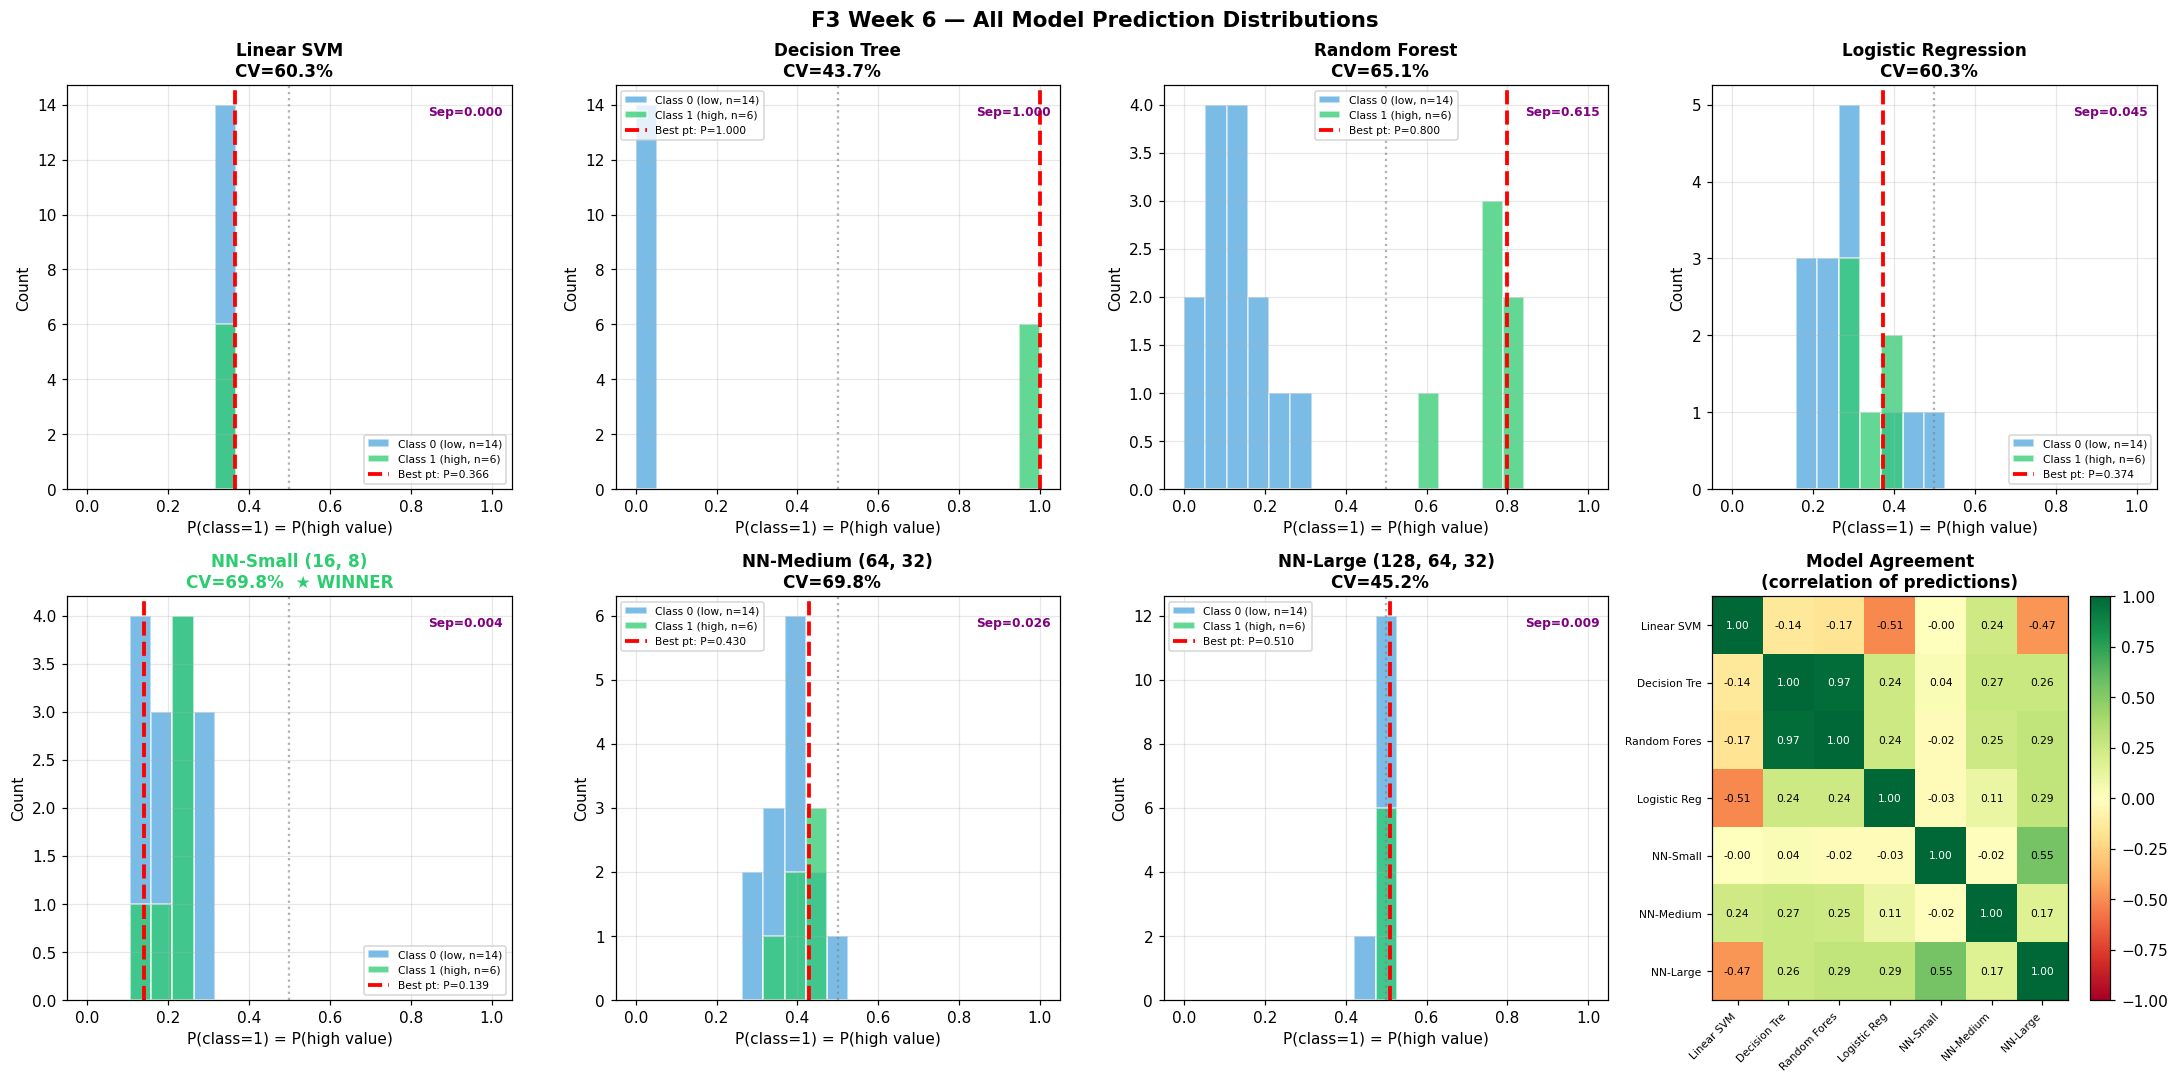

✅ Saved: F3_W6_Step6_ModelPredictions.png

  Model prediction summary (on training data):
  Model                            P(best pt)   Separation   CV Acc
  ─────────────────────────────────────────────────────────────────
  Linear SVM                           0.3660       0.0000    60.3%
  Decision Tree                        1.0000       1.0000    43.7%
  Random Forest                        0.8000       0.6145    65.1%
  Logistic Regression                  0.3736       0.0448    60.3%
  NN-Small (16, 8)                     0.1389       0.0040    69.8%
  NN-Medium (64, 32)                   0.4296       0.0256    69.8%
  NN-Large (128, 64, 32)               0.5103       0.0091    45.2%


In [8]:
# ── Visualisation: P(class=1) distributions per model ─────────
n_models = len(trained_models)
model_names = list(trained_models.keys())
colors_models = plt.cm.Set2(np.linspace(0, 1, n_models))

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
fig.suptitle(f'{FUNCTION_ID} Week {WEEK} — All Model Prediction Distributions',
             fontsize=14, fontweight='bold')
axes = axes.ravel()

for i, (name, proba) in enumerate(all_probas.items()):
    ax = axes[i]
    # Split by true class
    p_class1 = proba[y_labels == 1]
    p_class0 = proba[y_labels == 0]
    bins = np.linspace(0, 1, 20)
    ax.hist(p_class0, bins=bins, alpha=0.65, color='#3498db',
            label=f'Class 0 (low, n={len(p_class0)})', edgecolor='white')
    ax.hist(p_class1, bins=bins, alpha=0.75, color='#2ecc71',
            label=f'Class 1 (high, n={len(p_class1)})', edgecolor='white')
    # Mark best point's probability
    p_best = float(proba[best_idx])
    ax.axvline(p_best, color='red', linewidth=2.5, linestyle='--',
               label=f'Best pt: P={p_best:.3f}')
    ax.axvline(0.5, color='gray', linewidth=1.5, linestyle=':', alpha=0.6)
    ax.set_xlabel('P(class=1) = P(high value)')
    ax.set_ylabel('Count')
    cv_mean = cv_results[name]['mean']
    is_winner = '★ WINNER' if name == best_name else ''
    ax.set_title(f'{name}\nCV={cv_mean:.1%}  {is_winner}',
                 fontweight='bold', color='#2ecc71' if name == best_name else 'black')
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)
    # Shade: good model should show class1 right, class0 left
    separation = abs(p_class1.mean() - p_class0.mean()) if len(p_class1) > 0 and len(p_class0) > 0 else 0
    ax.text(0.98, 0.95, f'Sep={separation:.3f}', transform=ax.transAxes,
            ha='right', va='top', fontsize=8, color='purple', fontweight='bold')

# Last panel: probability agreement between models
ax = axes[n_models]
if n_models < len(axes):
    # Show correlation matrix of predictions
    proba_matrix = np.vstack([all_probas[n] for n in model_names]).T  # (samples, models)
    corr = np.corrcoef(proba_matrix.T)
    im = ax.imshow(corr, cmap='RdYlGn', vmin=-1, vmax=1, aspect='auto')
    ax.set_xticks(range(n_models))
    ax.set_yticks(range(n_models))
    short_names = [n.split('(')[0][:12].strip() for n in model_names]
    ax.set_xticklabels(short_names, rotation=45, ha='right', fontsize=7)
    ax.set_yticklabels(short_names, fontsize=7)
    for ii in range(n_models):
        for jj in range(n_models):
            ax.text(jj, ii, f'{corr[ii,jj]:.2f}', ha='center', va='center',
                    fontsize=7, color='black' if abs(corr[ii,jj]) < 0.7 else 'white')
    plt.colorbar(im, ax=ax)
    ax.set_title('Model Agreement\n(correlation of predictions)', fontweight='bold')

# Hide any remaining empty axes
for j in range(n_models + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.savefig(f'{FUNCTION_ID}_W{WEEK}_Step6_ModelPredictions.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'✅ Saved: {FUNCTION_ID}_W{WEEK}_Step6_ModelPredictions.png')
print()
print('  Model prediction summary (on training data):')
print(f'  {"Model":<30} {"P(best pt)":>12} {"Separation":>12} {"CV Acc":>8}')
print('  ' + '─'*65)
for name, proba in all_probas.items():
    p1 = proba[y_labels==1]
    p0 = proba[y_labels==0]
    sep = abs(p1.mean() - p0.mean()) if len(p1)>0 and len(p0)>0 else 0
    print(f'  {name:<30} {float(proba[best_idx]):>12.4f} {sep:>12.4f} {cv_results[name]["mean"]:>8.1%}')

---
## 📊 STEP 7 — CV Model Comparison: Select Winner

Now we compare all 7 models formally by their **cross-validation accuracy** — the unbiased estimate of how well each will generalise to unseen points.

**What to look for:**
- A model comfortably above 50% is doing better than random
- High std across folds = unstable (might be unlucky on some folds due to small data)
- If all models perform similarly (~55-65%), the landscape is genuinely hard to classify — the GP's exploration component becomes more important
- The **winning model** filters 10,000 candidates before GP scoring

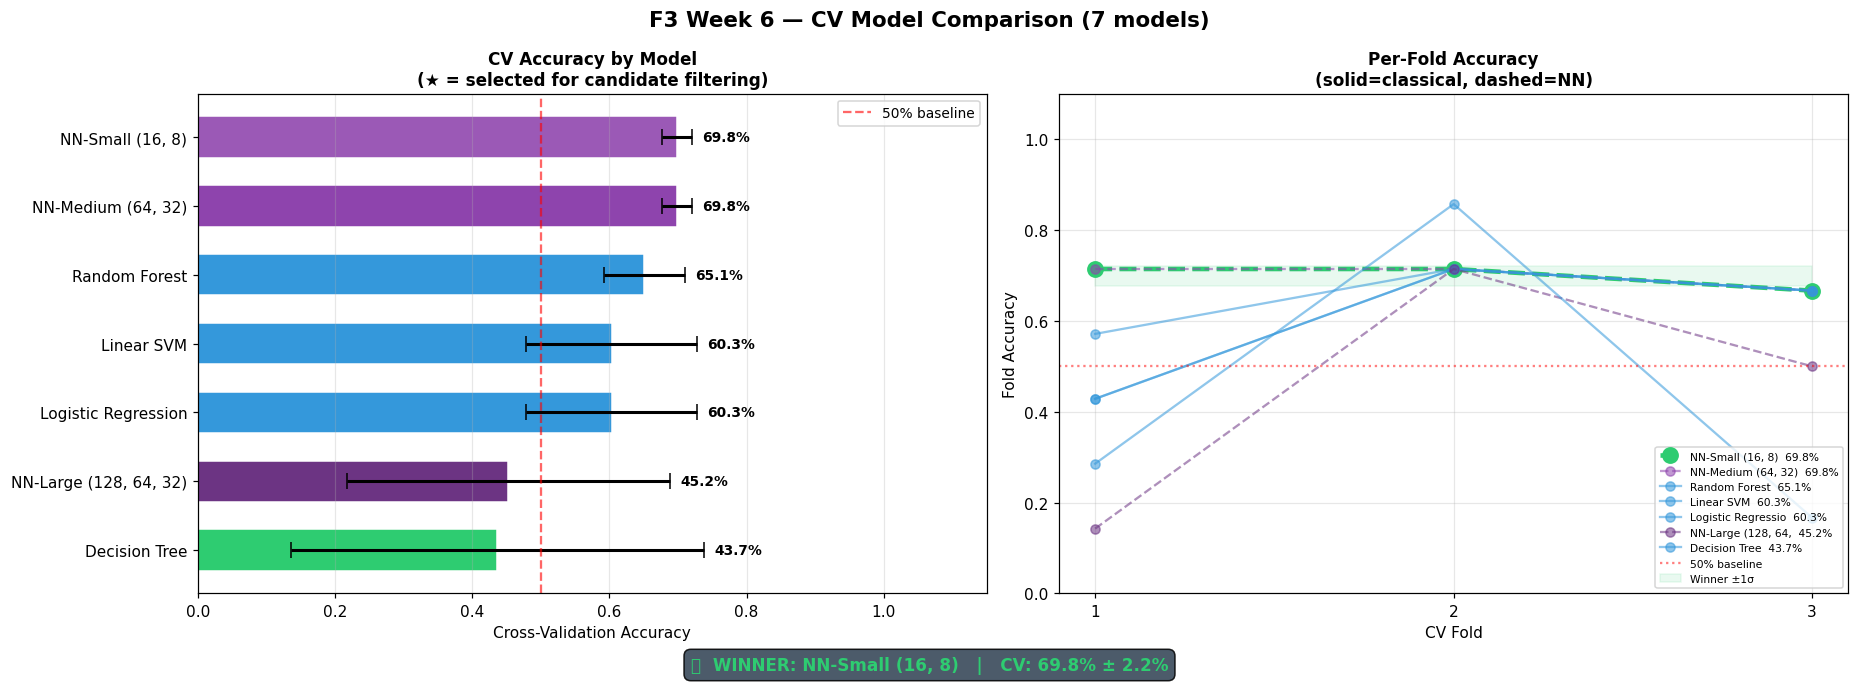

✅ Saved: F3_W6_Step7_ModelComparison.png


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(17, 6))
fig.suptitle(f'{FUNCTION_ID} Week {WEEK} — CV Model Comparison (7 models)',
             fontsize=14, fontweight='bold')

names  = [n for n, _ in ranked_models]
means  = [v['mean'] for _, v in ranked_models]
stds   = [v['std']  for _, v in ranked_models]
# Colour palette: winner=green, NNs=purple shades, classical=blue shades
def get_color(name, rank):
    if rank == 0: return '#2ecc71'
    if 'NN' in name: return ['#9b59b6','#8e44ad','#6c3483'][['Small','Medium','Large'].index(next((s for s in ['Small','Medium','Large'] if s in name), 'Small'))]
    return '#3498db'
bar_colors = [get_color(n, i) for i, n in enumerate(names[::-1])]

# Panel 1: Horizontal bars
ax = axes[0]
ax.barh(names[::-1], means[::-1], xerr=stds[::-1],
        color=bar_colors, edgecolor='white', height=0.6,
        capsize=5, error_kw={'linewidth':2, 'color':'#2c3e50'})
ax.axvline(0.5, color='red', linestyle='--', linewidth=1.5, alpha=0.6, label='50% baseline')
for i, (m, s) in enumerate(zip(means[::-1], stds[::-1])):
    ax.text(m + s + 0.015, i, f'{m:.1%}', va='center', fontsize=9, fontweight='bold')
ax.set_xlabel('Cross-Validation Accuracy')
ax.set_title('CV Accuracy by Model\n(★ = selected for candidate filtering)', fontweight='bold')
ax.set_xlim(0, 1.15)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3, axis='x')

# Panel 2: Per-fold lines
ax = axes[1]
fold_x = np.arange(1, n_cv_folds+1)
nn_names = [n for n in names if 'NN' in n]
classical_names = [n for n in names if 'NN' not in n]
for i, (name, info) in enumerate(ranked_models):
    lw    = 3.0 if name == best_name else 1.5
    alpha = 1.0 if name == best_name else 0.55
    ms    = 10  if name == best_name else 6
    color = get_color(name, i)
    ls    = '-' if 'NN' not in name else '--'
    ax.plot(fold_x, info['scores'], f'o{ls}', color=color, linewidth=lw,
            markersize=ms, alpha=alpha, label=f'{name[:18]}  {info["mean"]:.1%}')
ax.axhline(0.5, color='red', linestyle=':', linewidth=1.5, alpha=0.5, label='50% baseline')
ax.fill_between(fold_x, best_info['mean']-best_info['std'], best_info['mean']+best_info['std'],
                alpha=0.1, color='#2ecc71', label='Winner ±1σ')
ax.set_xlabel('CV Fold'); ax.set_ylabel('Fold Accuracy')
ax.set_title('Per-Fold Accuracy\n(solid=classical, dashed=NN)', fontweight='bold')
ax.set_ylim(0, 1.1); ax.set_xticks(fold_x)
ax.legend(fontsize=7, loc='lower right'); ax.grid(True, alpha=0.3)

fig.text(0.5, -0.02,
         f'✅  WINNER: {best_name}   |   CV: {best_info["mean"]:.1%} ± {best_info["std"]:.1%}',
         ha='center', fontsize=11, color='#2ecc71', fontweight='bold',
         bbox=dict(boxstyle='round,pad=0.4', facecolor='#2c3e50', alpha=0.85))

plt.tight_layout()
plt.savefig(f'{FUNCTION_ID}_W{WEEK}_Step7_ModelComparison.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'✅ Saved: {FUNCTION_ID}_W{WEEK}_Step7_ModelComparison.png')

---
## 🎲 STEP 8 — Generate & Filter Candidates

We generate **10,000 candidate points** in two phases:

**80% Exploitation** — Gaussian samples tightly around the best-known point (σ=0.05 in [0,1]^d). This gives us a dense cloud near where we already know the function peaks.

**20% Exploration** — Uniform random across the full [0,1]^d space. Ensures we don't completely miss unexplored regions.

The winning classifier then **scores all 10,000 candidates** by P(high value) and we discard the bottom 50% — leaving ~5,000 "probably good" candidates for the more expensive GP step.

In [10]:
best_clf = trained_models[best_name]
n_exploit = int(N_CANDIDATES * EXPLOIT_RATIO)
n_explore = N_CANDIDATES - n_exploit

X_exploit = np.clip(best_point + np.random.normal(0, EXPLOIT_SIGMA, (n_exploit, n_dims)), 0, 1)
X_explore = np.random.uniform(0, 1, (n_explore, n_dims))
X_cands   = np.vstack([X_exploit, X_explore])
src_tag   = np.array(['exploit']*n_exploit + ['explore']*n_explore)

X_cands_sc   = scaler.transform(X_cands)
proba_all    = best_clf.predict_proba(X_cands_sc)[:, 1]
keep_mask    = proba_all >= np.percentile(proba_all, FILTER_PERCENTILE)
X_filt       = X_cands[keep_mask]
proba_filt   = proba_all[keep_mask]
src_filt     = src_tag[keep_mask]

print('═'*65)
print('  CANDIDATE GENERATION & FILTERING')
print('═'*65)
print(f'  Generated  : {N_CANDIDATES:,}  ({n_exploit:,} exploit + {n_explore:,} explore)')
print(f'  Filtered by: {best_name}')
print(f'  Kept       : {len(X_filt):,} (top {100-FILTER_PERCENTILE}% by P(class=1))')
print(f'  Exploit %  : {100*np.mean(src_filt=="exploit"):.1f}%')
print(f'  Prob range : [{proba_filt.min():.3f}, {proba_filt.max():.3f}]')
print(f'\n  → {len(X_filt):,} candidates passed to Gaussian Process')

═════════════════════════════════════════════════════════════════
  CANDIDATE GENERATION & FILTERING
═════════════════════════════════════════════════════════════════
  Generated  : 10,000  (7,500 exploit + 2,500 explore)
  Filtered by: NN-Small (16, 8)
  Kept       : 5,000 (top 50% by P(class=1))
  Exploit %  : 54.7%
  Prob range : [0.141, 0.300]

  → 5,000 candidates passed to Gaussian Process


---
## 🔬 STEP 9 — Gaussian Process Regression

The GP is our **probabilistic surrogate model**. It gives two outputs for any input:
- **μ (mean)** — best estimate of the true function value
- **σ (std)** — uncertainty. Near training data = low σ. Far away = high σ

**Matern 5/2 kernel** is chosen because it:
- Allows sharper transitions than the smooth RBF kernel
- Assumes the function is twice differentiable (reasonable for most BBO functions)
- Works well empirically across a wide range of black-box problems

**`normalize_y=True`** is important when function values span a wide range — it internally standardises the y-values before fitting, improving numerical stability.

**`alpha=1e-6`** is a small nugget term added to the diagonal of the kernel matrix — essential for numerical stability, equivalent to assuming very small observation noise.

In [11]:
kernel = C(1.0, (1e-3, 1e3)) * Matern(length_scale=1.0, length_scale_bounds=(1e-2, 1e2), nu=2.5)
gp = GaussianProcessRegressor(kernel=kernel, alpha=1e-6, normalize_y=True,
                               n_restarts_optimizer=GP_RESTARTS, random_state=RANDOM_SEED)
gp.fit(X_scaled, y_train)

y_pred_tr, y_std_tr = gp.predict(X_scaled, return_std=True)
ss_res = np.sum((y_train - y_pred_tr)**2)
ss_tot = np.sum((y_train - y_train.mean())**2)
r2   = 1 - ss_res/ss_tot if ss_tot > 0 else 0.0
rmse = np.sqrt(np.mean((y_train - y_pred_tr)**2))

X_filt_sc = scaler.transform(X_filt)
mu, sigma = gp.predict(X_filt_sc, return_std=True)

print('═'*65)
print('  GAUSSIAN PROCESS REGRESSION')
print('═'*65)
print(f'  Kernel       : Matern ν=5/2 + Constant')
print(f'  Fitted kernel: {gp.kernel_}')
print(f'  R²           : {r2:.4f}  {"✅ Good" if r2>0.7 else "⚠️ Moderate" if r2>0.4 else "❌ Poor"}')
print(f'  RMSE         : {rmse:.6f}')
print(f'  μ range      : [{mu.min():.4f}, {mu.max():.4f}]')
print(f'  σ range      : [{sigma.min():.4f}, {sigma.max():.4f}]')

═════════════════════════════════════════════════════════════════
  GAUSSIAN PROCESS REGRESSION
═════════════════════════════════════════════════════════════════
  Kernel       : Matern ν=5/2 + Constant
  Fitted kernel: 1.08**2 * Matern(length_scale=0.582, nu=2.5)
  R²           : 1.0000  ✅ Good
  RMSE         : 0.000000
  μ range      : [-0.3646, -0.0135]
  σ range      : [0.0057, 0.0841]


---
## 🎯 STEP 10 — Acquisition Functions: EI & UCB

**Expected Improvement (EI)** is our primary acquisition function:
$$EI(x) = (\mu(x) - y_{best} - \xi)\cdot\Phi(Z) + \sigma(x)\cdot\phi(Z), \quad Z = \frac{\mu(x) - y_{best} - \xi}{\sigma(x)}$$

For **MAXIMIZATION**: improvement = μ − y_best. Points where μ > y_best with high confidence give high EI (exploitation). Points where σ is large can also give high EI even if μ < y_best (exploration).

**UCB** is a simpler alternative:
$$UCB(x) = \mu(x) + \kappa \cdot \sigma(x)$$

For **MAXIMIZATION**: we **add** σ (not subtract). κ=2 means we're being optimistic up to ~2 standard deviations above the mean prediction.

In [12]:
# ── EI (Maximization) ─────────────────────────────────────────
imp     = mu - best_value - EI_XI
Z       = imp / (sigma + 1e-9)
EI_acq  = np.maximum(imp * norm.cdf(Z) + sigma * norm.pdf(Z), 0)
exploit_term = imp * norm.cdf(Z)
explore_term = sigma * norm.pdf(Z)

# ── UCB (Maximization: add sigma) ────────────────────────────
UCB_acq = mu + UCB_KAPPA * sigma

# ── Select best (ARGMAX — Maximization) ──────────────────────
best_ei_idx  = np.argmax(EI_acq)
best_ucb_idx = np.argmax(UCB_acq)

submission = X_filt[best_ei_idx]
sub_mu     = mu[best_ei_idx]
sub_sigma  = sigma[best_ei_idx]
sub_ei     = EI_acq[best_ei_idx]
sub_ucb    = UCB_acq[best_ei_idx]
sub_exp    = exploit_term[best_ei_idx]
sub_expl   = explore_term[best_ei_idx]

print('═'*65)
print('  ACQUISITION FUNCTIONS (MAXIMIZE ⬆️)')
print('═'*65)
print(f'  EI max  : {EI_acq.max():.6f}   UCB max: {UCB_acq.max():.6f}')
print(f'  EI > 0  : {100*np.mean(EI_acq>0):.1f}% of candidates')
print()
print(f'  ★ SELECTED (max EI):')
print(f'  Coords  : {submission}')
print(f'  μ       : {sub_mu:.6f}   σ: {sub_sigma:.6f}')
print(f'  EI      : {sub_ei:.6f}   UCB: {sub_ucb:.6f}')
z_sub = (sub_mu - best_value - EI_XI) / (sub_sigma + 1e-9)
print(f'  Z-score : {z_sub:.4f}')
print(f'  Exploit : {sub_exp:.6f} ({100*sub_exp/(sub_ei+1e-9):.1f}%)')
print(f'  Explore : {sub_expl:.6f} ({100*sub_expl/(sub_ei+1e-9):.1f}%)')
driver = 'EXPLOITATION' if sub_exp > sub_expl else 'EXPLORATION'
print(f'  Driver  : {driver}')
status = '✅ PREDICTS NEW BEST' if sub_mu > best_value else '✅ PREDICTS RECOVERY' if sub_mu > latest_val else '🔍 EXPLORING'
print(f'  Status  : {status}  (μ={sub_mu:.4f} vs best={best_value:.4f})')

═════════════════════════════════════════════════════════════════
  ACQUISITION FUNCTIONS (MAXIMIZE ⬆️)
═════════════════════════════════════════════════════════════════
  EI max  : 0.011336   UCB max: 0.092918
  EI > 0  : 100.0% of candidates

  ★ SELECTED (max EI):
  Coords  : [1.         0.59792072 0.48524814]
  μ       : -0.043414   σ: 0.066807
  EI      : 0.011336   UCB: 0.090200
  Z-score : -0.5963
  Exploit : -0.010975 (-96.8%)
  Explore : 0.022311 (196.8%)
  Driver  : EXPLORATION
  Status  : ✅ PREDICTS RECOVERY  (μ=-0.0434 vs best=-0.0136)


---
## 📈 STEP 11 — Acquisition Curves: Global + Per Dimension

### Global acquisition curves
These show the **sorted EI and UCB scores** across all filtered candidates — how steeply one point dominates tells us how confident the GP is.

### Per-Dimension Acquisition Curves

This is a powerful diagnostic: for each dimension separately, we sweep that dimension from 0 to 1 (holding all others fixed at the best-known point) and compute how EI and UCB change.

**What to look for:**
- **Sharp peak**: that dimension has a clear optimal value — be precise here
- **Flat curve**: that dimension doesn't matter much — safe to leave near current best
- **Rising edge at boundary**: function wants this dimension pushed to 0 or 1 — be aware of boundary effects
- **Multiple peaks**: non-unimodal in that dimension — multiple good regions exist

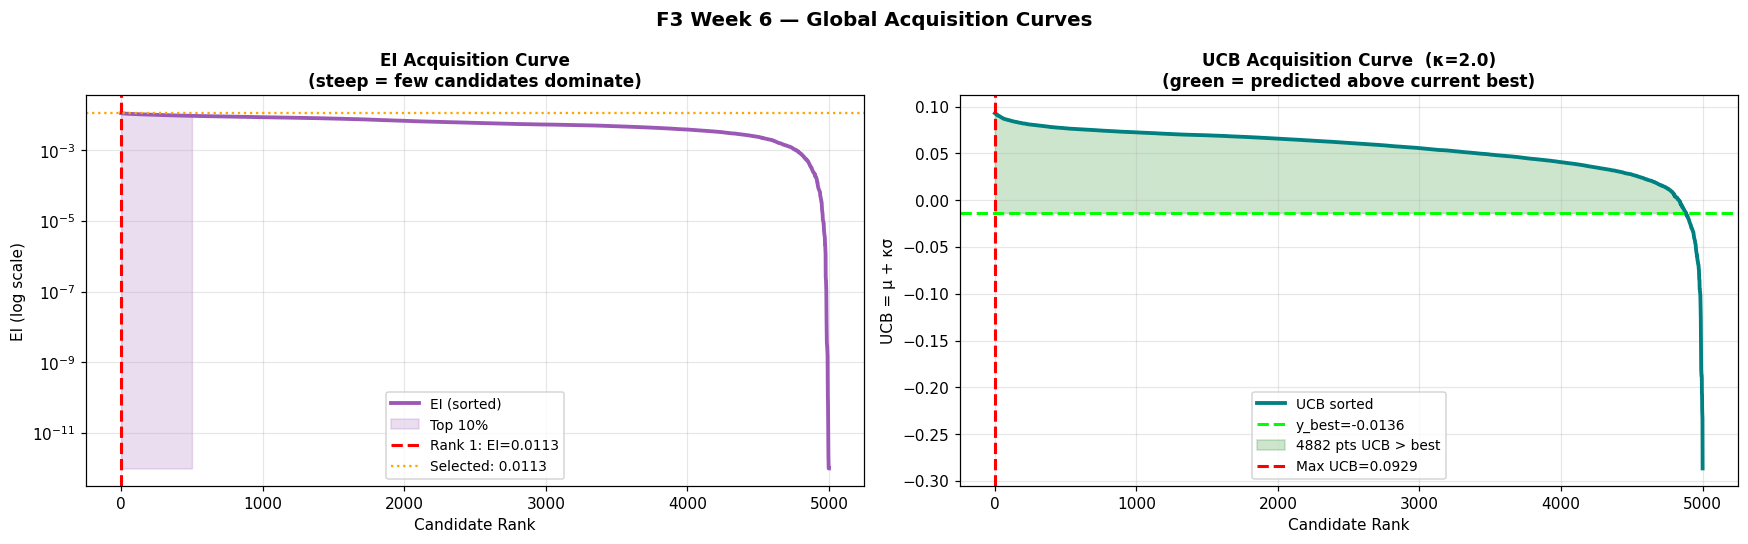

✅ Saved: F3_W6_Step11a_GlobalAcquisition.png


In [13]:
# ── Global acquisition curves ─────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle(f'{FUNCTION_ID} Week {WEEK} — Global Acquisition Curves', fontsize=13, fontweight='bold')

ei_sorted  = np.sort(EI_acq)[::-1]
ucb_sorted = np.sort(UCB_acq)[::-1]
rank_x = np.arange(1, len(ei_sorted)+1)

ax = axes[0]
ax.semilogy(rank_x, ei_sorted + 1e-12, color='#9b59b6', linewidth=2.5, label='EI (sorted)')
ax.fill_between(rank_x[:len(rank_x)//10], ei_sorted[:len(rank_x)//10]+1e-12,
                1e-12, alpha=0.2, color='#9b59b6', label='Top 10%')
ax.axvline(1, color='red', linewidth=2, linestyle='--', label=f'Rank 1: EI={ei_sorted[0]:.4f}')
ax.axhline(sub_ei, color='orange', linewidth=1.5, linestyle=':', label=f'Selected: {sub_ei:.4f}')
ax.set_xlabel('Candidate Rank'); ax.set_ylabel('EI (log scale)')
ax.set_title('EI Acquisition Curve\n(steep = few candidates dominate)', fontweight='bold')
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

ax = axes[1]
ax.plot(rank_x, ucb_sorted, color='teal', linewidth=2.5, label='UCB sorted')
ax.axhline(best_value, color='lime', linewidth=2, linestyle='--',
           label=f'y_best={best_value:.4f}')
n_above = np.sum(ucb_sorted > best_value)
if n_above > 0:
    ax.fill_between(rank_x[:n_above], best_value, ucb_sorted[:n_above],
                    alpha=0.2, color='green', label=f'{n_above} pts UCB > best')
ax.axvline(1, color='red', linewidth=2, linestyle='--', label=f'Max UCB={ucb_sorted[0]:.4f}')
ax.set_xlabel('Candidate Rank'); ax.set_ylabel('UCB = μ + κσ')
ax.set_title(f'UCB Acquisition Curve  (κ={UCB_KAPPA})\n(green = predicted above current best)', fontweight='bold')
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{FUNCTION_ID}_W{WEEK}_Step11a_GlobalAcquisition.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'✅ Saved: {FUNCTION_ID}_W{WEEK}_Step11a_GlobalAcquisition.png')

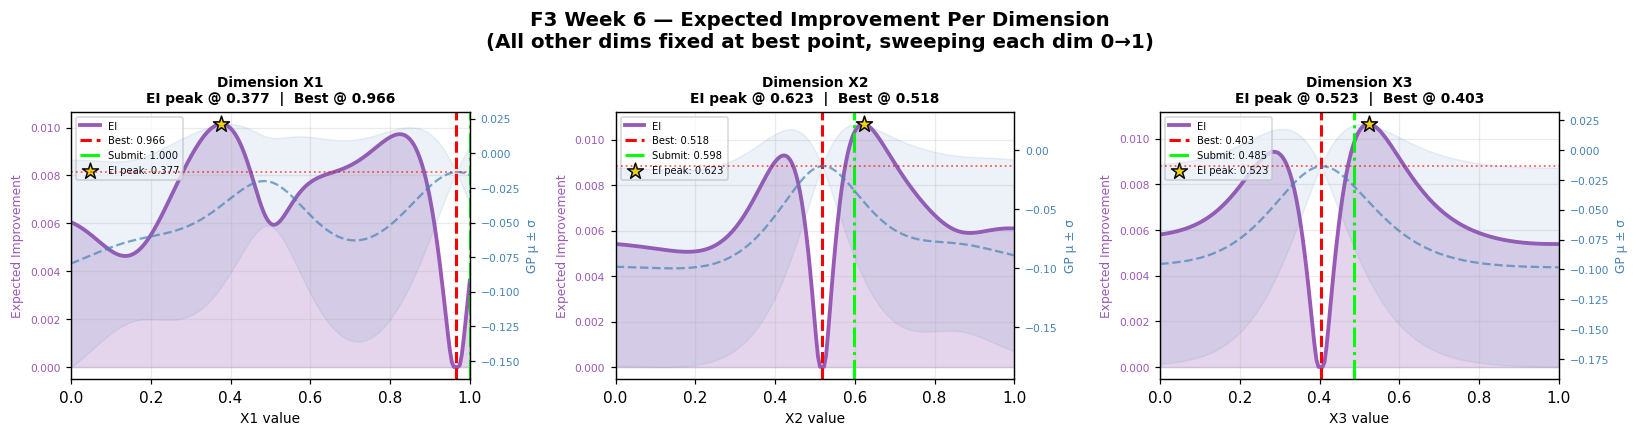

✅ Saved: F3_W6_Step11b_EI_PerDimension.png


In [14]:
# ── Per-Dimension Acquisition Curves ─────────────────────────
# For each dimension: sweep 0→1, fix all others at best_point value
# Shows how EI and UCB respond to each individual dimension

n_sweep = 200
sweep_vals = np.linspace(0, 1, n_sweep)

dim_ei_curves  = []
dim_ucb_curves = []
dim_mu_curves  = []
dim_sig_curves = []

for d in range(n_dims):
    pts = np.tile(best_point, (n_sweep, 1))
    pts[:, d] = sweep_vals
    pts_sc = scaler.transform(pts)
    mu_d, sig_d = gp.predict(pts_sc, return_std=True)
    imp_d  = mu_d - best_value - EI_XI
    Z_d    = imp_d / (sig_d + 1e-9)
    ei_d   = np.maximum(imp_d * norm.cdf(Z_d) + sig_d * norm.pdf(Z_d), 0)
    ucb_d  = mu_d + UCB_KAPPA * sig_d
    dim_ei_curves.append(ei_d)
    dim_ucb_curves.append(ucb_d)
    dim_mu_curves.append(mu_d)
    dim_sig_curves.append(sig_d)

# Determine grid layout
ncols = min(4, n_dims)
nrows_ei  = int(np.ceil(n_dims / ncols))

# ── Plot 1: EI per dimension ──────────────────────────────────
fig, axes = plt.subplots(nrows_ei, ncols, figsize=(5*ncols, 4*nrows_ei))
fig.suptitle(f'{FUNCTION_ID} Week {WEEK} — Expected Improvement Per Dimension\n'
             f'(All other dims fixed at best point, sweeping each dim 0→1)',
             fontsize=13, fontweight='bold')
if n_dims == 1:
    axes = np.array([[axes]])
elif nrows_ei == 1:
    axes = axes.reshape(1, -1)
axes_flat = axes.ravel()

for d in range(n_dims):
    ax = axes_flat[d]
    ei_d   = dim_ei_curves[d]
    sig_d  = dim_sig_curves[d]
    mu_d   = dim_mu_curves[d]

    # EI curve
    ax.fill_between(sweep_vals, 0, ei_d, alpha=0.25, color='#9b59b6')
    ax.plot(sweep_vals, ei_d, color='#9b59b6', linewidth=2.5, label='EI')

    # μ on twin axis
    ax2 = ax.twinx()
    ax2.plot(sweep_vals, mu_d, color='steelblue', linewidth=1.5, linestyle='--',
             alpha=0.7, label='GP μ')
    ax2.fill_between(sweep_vals, mu_d - sig_d, mu_d + sig_d,
                     alpha=0.1, color='steelblue')
    ax2.axhline(best_value, color='red', linestyle=':', linewidth=1.2, alpha=0.6)
    ax2.set_ylabel('GP μ ± σ', color='steelblue', fontsize=8)
    ax2.tick_params(axis='y', labelcolor='steelblue', labelsize=7)

    # Best point value in this dim
    ax.axvline(best_point[d], color='red', linewidth=2, linestyle='--',
               label=f'Best: {best_point[d]:.3f}')
    # Submission value in this dim
    ax.axvline(submission[d], color='lime', linewidth=2, linestyle='-.',
               label=f'Submit: {submission[d]:.3f}')

    # Mark EI peak
    ei_peak_idx = np.argmax(ei_d)
    if ei_d[ei_peak_idx] > 0:
        ax.scatter(sweep_vals[ei_peak_idx], ei_d[ei_peak_idx],
                   c='gold', s=120, marker='*', zorder=5,
                   edgecolors='black', linewidths=1,
                   label=f'EI peak: {sweep_vals[ei_peak_idx]:.3f}')

    ax.set_xlabel(f'X{d+1} value', fontsize=9)
    ax.set_ylabel('Expected Improvement', color='#9b59b6', fontsize=8)
    ax.tick_params(axis='y', labelcolor='#9b59b6', labelsize=7)
    ax.set_xlim(0, 1)
    ax.set_title(f'Dimension X{d+1}\nEI peak @ {sweep_vals[np.argmax(ei_d)]:.3f}  |  Best @ {best_point[d]:.3f}',
                 fontweight='bold', fontsize=9)
    ax.legend(fontsize=6.5, loc='upper left')
    ax.grid(True, alpha=0.25)

for j in range(n_dims, len(axes_flat)):
    axes_flat[j].set_visible(False)

plt.tight_layout()
plt.savefig(f'{FUNCTION_ID}_W{WEEK}_Step11b_EI_PerDimension.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'✅ Saved: {FUNCTION_ID}_W{WEEK}_Step11b_EI_PerDimension.png')

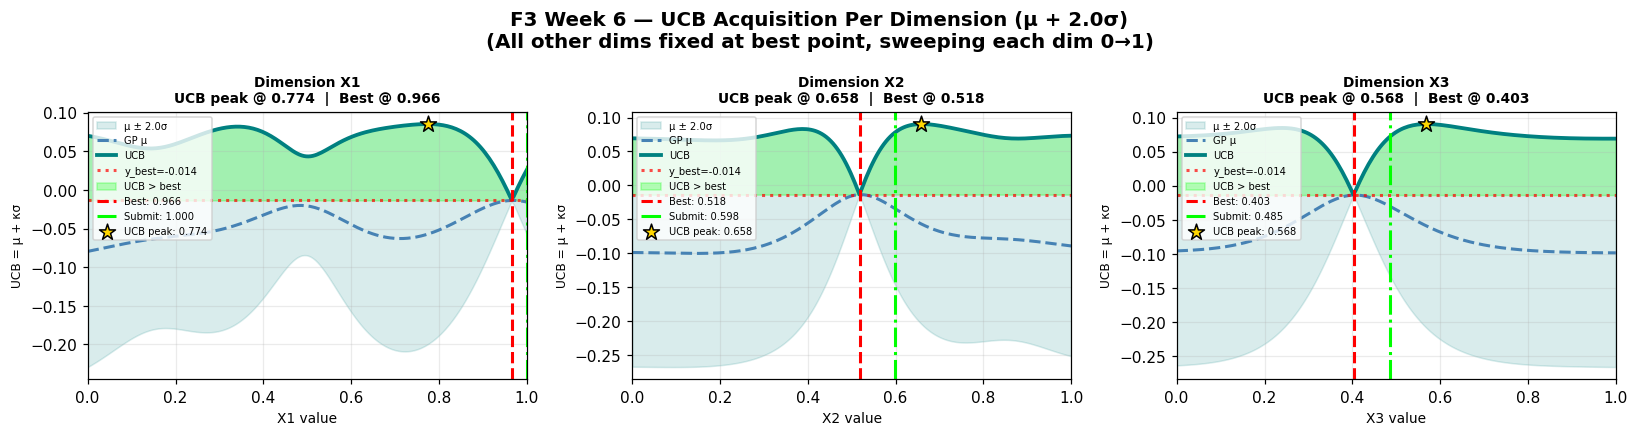

✅ Saved: F3_W6_Step11c_UCB_PerDimension.png

  PER-DIMENSION SUMMARY:
  Dim      Best val    EI peak   UCB peak    Agreement
  ────────────────────────────────────────────────────
  X1         0.9660     0.3769     0.7739    ⚠️ differ
  X2         0.5177     0.6231     0.6583      ✅ agree
  X3         0.4028     0.5226     0.5678      ✅ agree


In [15]:
# ── Plot 2: UCB per dimension ─────────────────────────────────
fig, axes = plt.subplots(nrows_ei, ncols, figsize=(5*ncols, 4*nrows_ei))
fig.suptitle(f'{FUNCTION_ID} Week {WEEK} — UCB Acquisition Per Dimension (μ + {UCB_KAPPA}σ)\n'
             f'(All other dims fixed at best point, sweeping each dim 0→1)',
             fontsize=13, fontweight='bold')
if n_dims == 1:
    axes = np.array([[axes]])
elif nrows_ei == 1:
    axes = axes.reshape(1, -1)
axes_flat = axes.ravel()

for d in range(n_dims):
    ax = axes_flat[d]
    ucb_d = dim_ucb_curves[d]
    mu_d  = dim_mu_curves[d]
    sig_d = dim_sig_curves[d]

    ax.fill_between(sweep_vals, mu_d - UCB_KAPPA*sig_d, mu_d + UCB_KAPPA*sig_d,
                    alpha=0.15, color='teal', label=f'μ ± {UCB_KAPPA}σ')
    ax.plot(sweep_vals, mu_d, color='steelblue', linewidth=2, linestyle='--', label='GP μ')
    ax.plot(sweep_vals, ucb_d, color='teal', linewidth=2.5, label='UCB')
    ax.axhline(best_value, color='red', linestyle=':', linewidth=2,
               alpha=0.7, label=f'y_best={best_value:.3f}')

    # Shade region where UCB > best
    above = ucb_d > best_value
    if np.any(above):
        ax.fill_between(sweep_vals, best_value, ucb_d, where=above,
                        alpha=0.25, color='lime', label='UCB > best')

    ax.axvline(best_point[d], color='red', linewidth=2, linestyle='--',
               label=f'Best: {best_point[d]:.3f}')
    ax.axvline(submission[d], color='lime', linewidth=2, linestyle='-.',
               label=f'Submit: {submission[d]:.3f}')

    ucb_peak = np.argmax(ucb_d)
    ax.scatter(sweep_vals[ucb_peak], ucb_d[ucb_peak], c='gold', s=120,
               marker='*', zorder=5, edgecolors='black', linewidths=1,
               label=f'UCB peak: {sweep_vals[ucb_peak]:.3f}')

    ax.set_xlabel(f'X{d+1} value', fontsize=9)
    ax.set_ylabel('UCB = μ + κσ', fontsize=8)
    ax.set_xlim(0, 1)
    ax.set_title(f'Dimension X{d+1}\nUCB peak @ {sweep_vals[ucb_peak]:.3f}  |  Best @ {best_point[d]:.3f}',
                 fontweight='bold', fontsize=9)
    ax.legend(fontsize=6.5, loc='upper left')
    ax.grid(True, alpha=0.25)

for j in range(n_dims, len(axes_flat)):
    axes_flat[j].set_visible(False)

plt.tight_layout()
plt.savefig(f'{FUNCTION_ID}_W{WEEK}_Step11c_UCB_PerDimension.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'✅ Saved: {FUNCTION_ID}_W{WEEK}_Step11c_UCB_PerDimension.png')

# Summary table
print()
print('  PER-DIMENSION SUMMARY:')
print(f'  {"Dim":<6} {"Best val":>10} {"EI peak":>10} {"UCB peak":>10} {"Agreement":>12}')
print('  ' + '─'*52)
for d in range(n_dims):
    ei_peak  = sweep_vals[np.argmax(dim_ei_curves[d])]
    ucb_peak = sweep_vals[np.argmax(dim_ucb_curves[d])]
    agree    = '✅ agree' if abs(ei_peak - ucb_peak) < 0.1 else '⚠️ differ'
    print(f'  X{d+1:<5} {best_point[d]:>10.4f} {ei_peak:>10.4f} {ucb_peak:>10.4f} {agree:>12}')

---
## 🗺️ STEP 12 — Acquisition Surface Visualisations

For the **two most sensitive dimensions** (found by GP gradient analysis), we plot 2D contour surfaces of μ, EI, and UCB. All other dimensions are fixed at the best-known values.

This gives us a direct spatial view of where the GP thinks the landscape peaks and where the acquisition functions want us to go next.

  Top 2 sensitive dims: X2 (0.0252), X3 (0.0223)


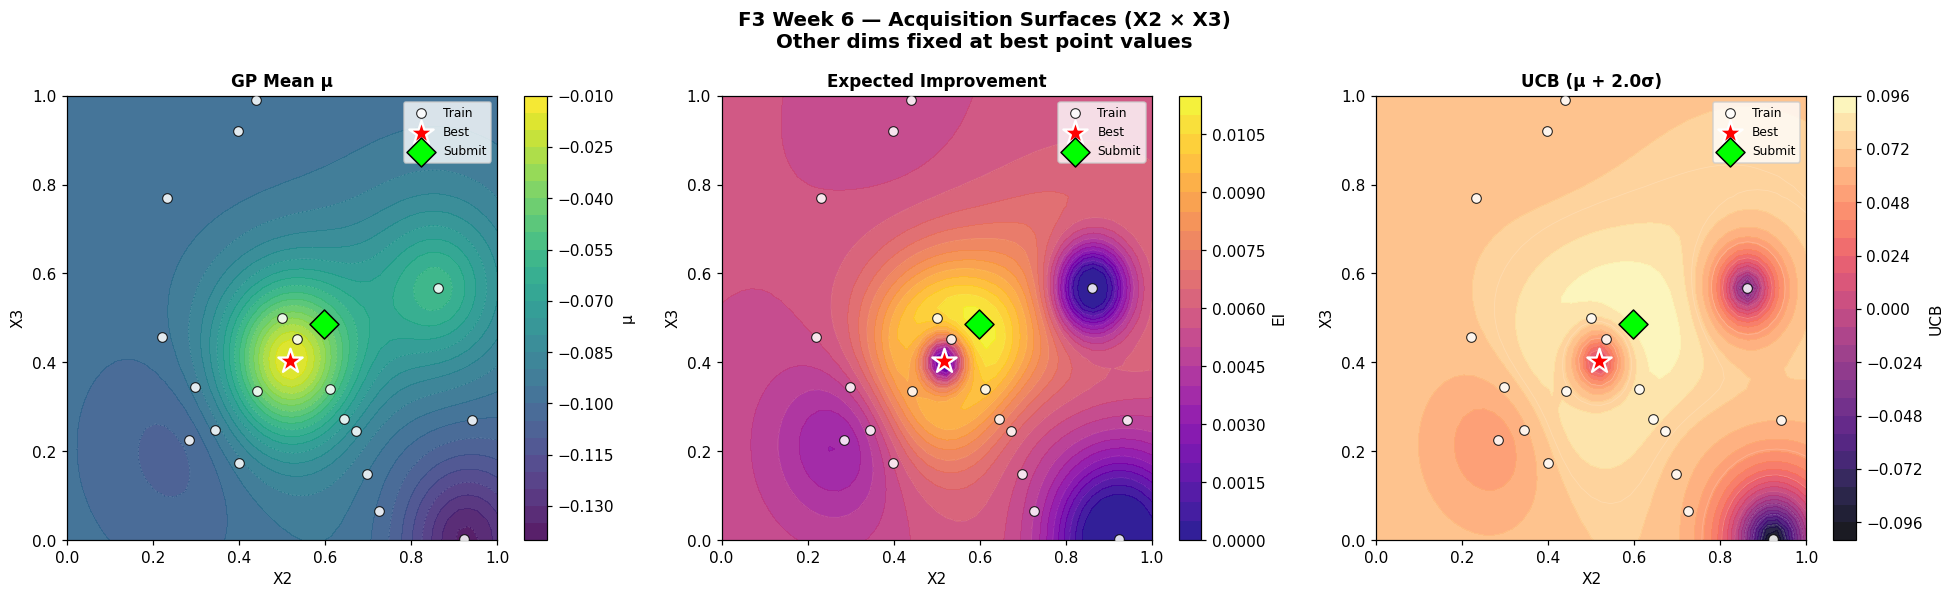

✅ Saved: F3_W6_Step12_AcquisitionSurface.png


In [16]:
# Sensitivity analysis to find top 2 dims
delta = 0.01
sensitivities = []
for d in range(n_dims):
    p_up = best_point.copy(); p_up[d] = min(1.0, best_point[d]+delta)
    p_dn = best_point.copy(); p_dn[d] = max(0.0, best_point[d]-delta)
    m_up, _ = gp.predict(scaler.transform(p_up.reshape(1,-1)), return_std=True)
    m_dn, _ = gp.predict(scaler.transform(p_dn.reshape(1,-1)), return_std=True)
    sensitivities.append(abs(float(m_up) - float(m_dn)) / (2*delta))
top2 = np.argsort(sensitivities)[::-1][:2]
d1, d2 = top2[0], top2[1]

print(f'  Top 2 sensitive dims: X{d1+1} ({sensitivities[d1]:.4f}), X{d2+1} ({sensitivities[d2]:.4f})')

# Build grid
g_res = 45
g1, g2 = np.linspace(0,1,g_res), np.linspace(0,1,g_res)
G1, G2 = np.meshgrid(g1, g2)
grid_pts = np.tile(best_point, (g_res*g_res, 1))
grid_pts[:, d1] = G1.ravel(); grid_pts[:, d2] = G2.ravel()
grid_sc = scaler.transform(grid_pts)
mg, sg = gp.predict(grid_sc, return_std=True)
ig = mg - best_value - EI_XI; Zg = ig/(sg+1e-9)
EIg = np.maximum(ig*norm.cdf(Zg) + sg*norm.pdf(Zg), 0)
UCBg = mg + UCB_KAPPA*sg

fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))
fig.suptitle(f'{FUNCTION_ID} Week {WEEK} — Acquisition Surfaces (X{d1+1} × X{d2+1})\n'
             f'Other dims fixed at best point values', fontsize=13, fontweight='bold')

for ax, Z_grid, title, cmap, clabel in [
    (axes[0], mg.reshape(g_res,g_res),   f'GP Mean μ', 'viridis', 'μ'),
    (axes[1], EIg.reshape(g_res,g_res),  'Expected Improvement', 'plasma', 'EI'),
    (axes[2], UCBg.reshape(g_res,g_res), f'UCB (μ + {UCB_KAPPA}σ)', 'magma', 'UCB'),
]:
    cf  = ax.contourf(G1, G2, Z_grid, levels=25, cmap=cmap, alpha=0.9)
    ax.contour(G1, G2, Z_grid, levels=8, colors='white', alpha=0.2, linewidths=0.5)
    plt.colorbar(cf, ax=ax, label=clabel)
    ax.scatter(X_train[:,d1], X_train[:,d2], c='white', s=40,
               edgecolors='black', linewidths=0.7, zorder=4, alpha=0.85, label='Train')
    ax.scatter(best_point[d1], best_point[d2], c='red', s=280, marker='*',
               zorder=5, edgecolors='white', linewidths=1.5, label=f'Best')
    ax.scatter(submission[d1], submission[d2], c='lime', s=180, marker='D',
               zorder=6, edgecolors='black', linewidths=1, label='Submit')
    ax.set_xlabel(f'X{d1+1}'); ax.set_ylabel(f'X{d2+1}')
    ax.set_title(title, fontweight='bold')
    ax.legend(fontsize=8, loc='upper right')

plt.tight_layout()
plt.savefig(f'{FUNCTION_ID}_W{WEEK}_Step12_AcquisitionSurface.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'✅ Saved: {FUNCTION_ID}_W{WEEK}_Step12_AcquisitionSurface.png')

---
## 🏆 STEP 13 — Top Candidates & Submission Dashboard

Final review: top 5 candidates by EI, then the full submission dashboard combining all key information.

The dashboard gives a complete at-a-glance view: historical trajectory, predicted outcome, submission coordinates, EI decomposition, and all key metrics in a summary table.

In [17]:
top5 = np.argsort(EI_acq)[::-1][:5]
print('═'*70)
print('  TOP 5 CANDIDATES BY EI (MAXIMIZATION ⬆️)')
print('═'*70)
print(f'  {"Rank":<6} {"EI":>10} {"GP μ":>10} {"GP σ":>10} {"UCB":>10}  Source')
print('  ' + '─'*58)
for rank, idx in enumerate(top5, 1):
    star = '★' if rank == 1 else ' '
    print(f'  {star}#{rank:<4} {EI_acq[idx]:>10.6f} {mu[idx]:>10.4f} {sigma[idx]:>10.4f} {UCB_acq[idx]:>10.4f}  {src_filt[idx]}')
    print(f'          {X_filt[idx]}')
    print()

══════════════════════════════════════════════════════════════════════
  TOP 5 CANDIDATES BY EI (MAXIMIZATION ⬆️)
══════════════════════════════════════════════════════════════════════
  Rank           EI       GP μ       GP σ        UCB  Source
  ──────────────────────────────────────────────────────────
  ★#1      0.011336    -0.0434     0.0668     0.0902  exploit
          [1.         0.59792072 0.48524814]

   #2      0.011317    -0.0449     0.0680     0.0910  exploit
          [0.99174175 0.60077074 0.49104676]

   #3      0.011312    -0.0426     0.0661     0.0895  exploit
          [0.99055645 0.59083599 0.49208184]

   #4      0.011283    -0.0452     0.0681     0.0910  exploit
          [0.97761919 0.59697752 0.49847994]

   #5      0.011242    -0.0481     0.0703     0.0926  exploit
          [0.99462437 0.61345148 0.4901918 ]



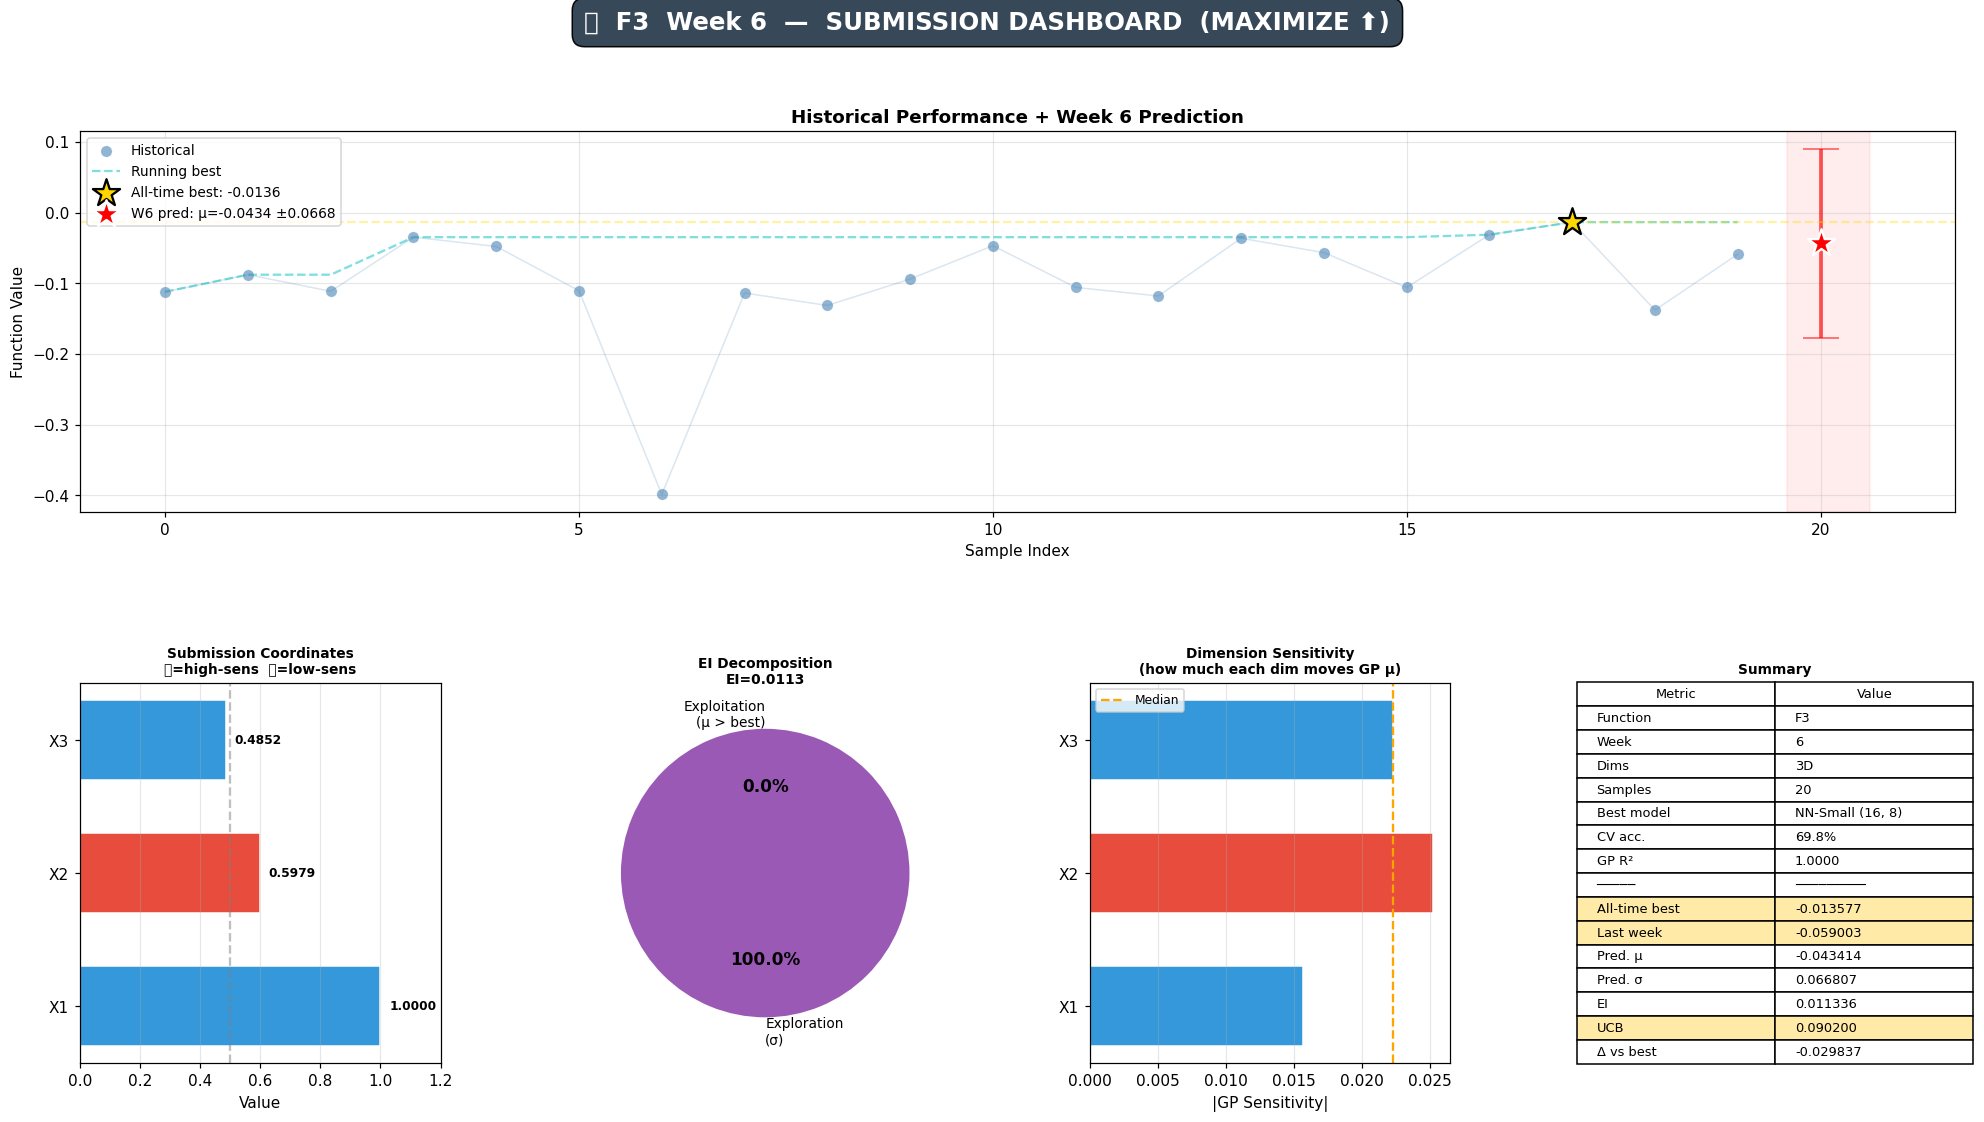

✅ Saved: F3_W6_Step13_Dashboard.png


In [18]:
# ── Submission Dashboard ──────────────────────────────────────
fig = plt.figure(figsize=(22, 11))
gs  = gridspec.GridSpec(2, 4, figure=fig, hspace=0.45, wspace=0.4)
fig.suptitle(f'🎯  {FUNCTION_ID}  Week {WEEK}  —  SUBMISSION DASHBOARD  (MAXIMIZE ⬆️)',
             fontsize=16, fontweight='bold', color='white',
             bbox=dict(boxstyle='round,pad=0.5', facecolor='#2c3e50', alpha=0.95))

# Panel 1: Full history + prediction
ax1 = fig.add_subplot(gs[0, :])
ax1.scatter(indices, y_train, c='steelblue', s=55, alpha=0.6, zorder=3,
            edgecolors='white', linewidths=0.3, label='Historical')
ax1.plot(indices, y_train, 'steelblue', alpha=0.2, linewidth=1)
ax1.plot(indices, np.maximum.accumulate(y_train), 'c--', linewidth=1.5, alpha=0.5, label='Running best')
ax1.scatter(best_idx, best_value, c='gold', s=350, marker='*', zorder=6,
            edgecolors='black', linewidths=1.5, label=f'All-time best: {best_value:.4f}')
ax1.errorbar(n_samples, sub_mu, yerr=2*sub_sigma,
             fmt='none', color='red', capsize=12, linewidth=2.5, alpha=0.65)
ax1.scatter(n_samples, sub_mu, c='red', s=350, marker='*', zorder=6,
            edgecolors='white', linewidths=1.5,
            label=f'W{WEEK} pred: μ={sub_mu:.4f} ±{sub_sigma:.4f}')
ax1.axhline(best_value, color='gold', linestyle='--', alpha=0.35, linewidth=1.5)
ax1.axvspan(n_samples-0.4, n_samples+0.6, alpha=0.07, color='red')
ax1.set_xlabel('Sample Index'); ax1.set_ylabel('Function Value')
ax1.set_title(f'Historical Performance + Week {WEEK} Prediction', fontweight='bold', fontsize=12)
ax1.legend(fontsize=9, loc='upper left'); ax1.grid(True, alpha=0.3)

# Panel 2: Submission coordinates
ax2 = fig.add_subplot(gs[1, 0])
dim_labels = [f'X{i+1}' for i in range(n_dims)]
sens_arr = np.array(sensitivities)
c_bars   = ['#e74c3c' if s > np.median(sens_arr) else '#3498db' for s in sens_arr]
ax2.barh(dim_labels, submission, color=c_bars, edgecolor='white', height=0.6)
for i, v in enumerate(submission):
    ax2.text(min(v+0.03, 1.1), i, f'{v:.4f}', va='center', fontsize=8, fontweight='bold')
ax2.axvline(0.5, color='gray', linestyle='--', alpha=0.5)
ax2.set_xlim(0, 1.2); ax2.set_xlabel('Value')
ax2.set_title('Submission Coordinates\n🔴=high-sens  🔵=low-sens', fontweight='bold', fontsize=9)
ax2.grid(True, alpha=0.3, axis='x')

# Panel 3: EI decomposition
ax3 = fig.add_subplot(gs[1, 1])
if sub_exp > 0 or sub_expl > 0:
    wedges, texts, autos = ax3.pie(
        [max(sub_exp,0), max(sub_expl,0)],
        labels=['Exploitation\n(μ > best)', 'Exploration\n(σ)'],
        colors=['#2ecc71','#9b59b6'], autopct='%1.1f%%',
        startangle=90, textprops={'fontsize':9})
    for a in autos: a.set_fontsize(11); a.set_fontweight('bold')
ax3.set_title(f'EI Decomposition\nEI={sub_ei:.4f}', fontweight='bold', fontsize=9)

# Panel 4: Dim sensitivities
ax4 = fig.add_subplot(gs[1, 2])
ax4.barh(dim_labels, sens_arr, color=c_bars, edgecolor='white', height=0.6)
ax4.axvline(np.median(sens_arr), color='orange', linestyle='--', linewidth=1.5, label='Median')
ax4.set_xlabel('|GP Sensitivity|')
ax4.set_title('Dimension Sensitivity\n(how much each dim moves GP μ)', fontweight='bold', fontsize=9)
ax4.legend(fontsize=8); ax4.grid(True, alpha=0.3, axis='x')

# Panel 5: Summary table
ax5 = fig.add_subplot(gs[1, 3])
ax5.axis('off')
rows = [
    ['Function',    FUNCTION_ID],
    ['Week',        str(WEEK)],
    ['Dims',        f'{n_dims}D'],
    ['Samples',     str(n_samples)],
    ['Best model',  best_name[:16]],
    ['CV acc.',     f'{best_info["mean"]:.1%}'],
    ['GP R²',       f'{r2:.4f}'],
    ['─────',       '─────────'],
    ['All-time best', f'{best_value:.6f}'],
    ['Last week',   f'{latest_val:.6f}'],
    ['Pred. μ',     f'{sub_mu:.6f}'],
    ['Pred. σ',     f'{sub_sigma:.6f}'],
    ['EI',          f'{sub_ei:.6f}'],
    ['UCB',         f'{sub_ucb:.6f}'],
    ['Δ vs best',   f'{sub_mu-best_value:+.6f}'],
]
tbl = ax5.table(cellText=rows, colLabels=['Metric','Value'],
                loc='center', cellLoc='left')
tbl.auto_set_font_size(False); tbl.set_fontsize(8.5); tbl.scale(1.1, 1.3)
for r in [9, 10, 14]:
    for c in [0,1]:
        try: tbl[r,c].set_facecolor('#ffeaa7')
        except: pass
ax5.set_title('Summary', fontweight='bold', fontsize=9)

plt.savefig(f'{FUNCTION_ID}_W{WEEK}_Step13_Dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'✅ Saved: {FUNCTION_ID}_W{WEEK}_Step13_Dashboard.png')

---
## 📋 STEP 14 — Final Formatted Submission

The winning point formatted as a dash-separated string — ready to copy directly into the BBO submission interface.

Saved as both `.npy` (for reuse in future notebooks) and `.txt` (for submission).

In [19]:
submission_str = '-'.join([f'{x:.6f}' for x in submission])

print('╔' + '═'*66 + '╗')
print(f'║  WEEK {WEEK} FINAL SUBMISSION — {FUNCTION_ID}{" "*(55 - len(FUNCTION_ID) - len(str(WEEK)))}║')
print('╠' + '═'*66 + '╣')
print(f'║  Method     : Adaptive Model (7 types) + GP/EI  MAXIMIZE ⬆️{" "*4}║')
print(f'║  Best model : {best_name:<25}  CV = {best_info["mean"]:.1%}{" "*8}║')
print(f'║  GP R²      : {r2:.4f}{" "*50}║')
print('╠' + '═'*66 + '╣')
print(f'║  GP μ       : {sub_mu:.6f}{" "*48}║')
print(f'║  GP σ       : {sub_sigma:.6f}{" "*48}║')
print(f'║  UCB        : {sub_ucb:.6f}{" "*48}║')
print(f'║  EI         : {sub_ei:.6f}{" "*48}║')
print('╠' + '═'*66 + '╣')
print(f'║  All-time best : {best_value:.6f}{" "*44}║')
print(f'║  Last week     : {latest_val:.6f}{" "*44}║')
print(f'║  Δ vs best     : {sub_mu - best_value:+.6f}{" "*44}║')
print('╠' + '═'*66 + '╣')
if sub_mu > best_value:
    msg = f'✅  GP PREDICTS NEW BEST: {sub_mu:.4f} > {best_value:.4f}'
elif sub_mu > latest_val:
    msg = f'✅  GP PREDICTS RECOVERY: {sub_mu:.4f} > {latest_val:.4f}'
else:
    msg = f'🔍  EXPLORING UNCERTAIN REGION  μ={sub_mu:.4f}'
print(f'║  {msg:<65}║')
print('╠' + '═'*66 + '╣')
print(f'║  📋  COPY THIS TO SUBMIT:{" "*41}║')
print(f'║{" "*68}║')
print(f'║  {submission_str:<66}║')
print(f'║{" "*68}║')
print('╚' + '═'*66 + '╝')

# Save
np.save(f'{FUNCTION_ID}_W{WEEK}_submission.npy', submission)
with open(f'{FUNCTION_ID}_W{WEEK}_submission.txt', 'w', encoding='utf-8') as f:
    f.write(f'# {FUNCTION_ID} Week {WEEK} | Method: Adaptive+GP/EI | MAXIMIZE\n')
    f.write(f'# Model: {best_name} CV={best_info["mean"]:.1%} | GP R2={r2:.4f}\n')
    f.write(f'# mu={sub_mu:.6f} sigma={sub_sigma:.6f} EI={sub_ei:.6f}\n')
    f.write(f'# best={best_value:.6f} delta={sub_mu-best_value:+.6f}\n')
    f.write(submission_str + '\n')

print(f'\n  💾 {FUNCTION_ID}_W{WEEK}_submission.npy')
print(f'  💾 {FUNCTION_ID}_W{WEEK}_submission.txt')
print()
print('  📊 ALL VISUALISATIONS:')
for step, name in [
    ('Step3',  'History'),
    ('Step6',  'ModelPredictions'),
    ('Step7',  'ModelComparison'),
    ('Step11a','GlobalAcquisition'),
    ('Step11b','EI_PerDimension'),
    ('Step11c','UCB_PerDimension'),
    ('Step12', 'AcquisitionSurface'),
    ('Step13', 'Dashboard'),
]:
    print(f'     {FUNCTION_ID}_W{WEEK}_{step}_{name}.png')

print()
print('  🎯  MAXIMIZATION — HIGHER IS ALWAYS BETTER ⬆️')

╔══════════════════════════════════════════════════════════════════╗
║  WEEK 6 FINAL SUBMISSION — F3                                                    ║
╠══════════════════════════════════════════════════════════════════╣
║  Method     : Adaptive Model (7 types) + GP/EI  MAXIMIZE ⬆️    ║
║  Best model : NN-Small (16, 8)           CV = 69.8%        ║
║  GP R²      : 1.0000                                                  ║
╠══════════════════════════════════════════════════════════════════╣
║  GP μ       : -0.043414                                                ║
║  GP σ       : 0.066807                                                ║
║  UCB        : 0.090200                                                ║
║  EI         : 0.011336                                                ║
╠══════════════════════════════════════════════════════════════════╣
║  All-time best : -0.013577                                            ║
║  Last week     : -0.059003                                    

---
## 💾 STEP 15 — Save Hyperparameter Record & Visualisation Index

### Why Keep a Hyperparameter Record?

Each week we tune parameters based on what we've learned. Without a written record it's impossible to:
- Know **why** a particular week performed well or poorly
- Compare parameter choices across weeks systematically
- Reproduce a run that gave a good result
- Build intuition about which settings work for which function types

This step saves a **complete, self-contained record** of everything used in this run:
- All hyperparameter values with their rationale
- GP kernel specification (fitted parameters, not just defaults)
- Model CV results for all 7 classifiers
- Selected model and its performance
- Submission point, predictions, and context
- Index of all visualisation files produced

Saved as: `{FUNCTION_ID}_W{WEEK}_hyperparameters.json` and `{FUNCTION_ID}_W{WEEK}_run_report.txt`

In [20]:
import json as _json
import os
from datetime import datetime

# ── 1. Collect all visualisation files produced ───────────────
viz_files = [
    f'{FUNCTION_ID}_W{WEEK}_Step3_History.png',
    f'{FUNCTION_ID}_W{WEEK}_Step6_ModelPredictions.png',
    f'{FUNCTION_ID}_W{WEEK}_Step7_ModelComparison.png',
    f'{FUNCTION_ID}_W{WEEK}_Step11a_GlobalAcquisition.png',
    f'{FUNCTION_ID}_W{WEEK}_Step11b_EI_PerDimension.png',
    f'{FUNCTION_ID}_W{WEEK}_Step11c_UCB_PerDimension.png',
    f'{FUNCTION_ID}_W{WEEK}_Step12_AcquisitionSurface.png',
    f'{FUNCTION_ID}_W{WEEK}_Step13_Dashboard.png',
]
viz_status = {f: os.path.exists(f) for f in viz_files}

# ── 2. GP kernel details ──────────────────────────────────────
kernel_str  = str(gp.kernel_)
kernel_init = str(gp.kernel)
gp_params   = gp.kernel_.get_params()
# Extract fitted length scale and amplitude cleanly
gp_param_clean = {k: float(v) if hasattr(v, '__float__') else str(v)
                  for k, v in gp_params.items()}

# ── 3. Model CV results ───────────────────────────────────────
model_records = {}
for name, info in cv_results.items():
    model_records[name] = {
        'cv_mean'   : round(float(info['mean']), 6),
        'cv_std'    : round(float(info['std']),  6),
        'cv_folds'  : [round(float(s), 6) for s in info['scores']],
        'selected'  : name == best_name,
        'type'      : 'neural_network' if 'NN' in name else 'classical',
    }

# ── 4. Dimension analysis ─────────────────────────────────────
dim_records = {}
for d in range(n_dims):
    ei_peak_val  = float(sweep_vals[int(np.argmax(dim_ei_curves[d]))])
    ucb_peak_val = float(sweep_vals[int(np.argmax(dim_ucb_curves[d]))])
    dim_records[f'X{d+1}'] = {
        'best_point_value' : round(float(best_point[d]), 6),
        'submission_value' : round(float(submission[d]), 6),
        'gp_sensitivity'   : round(float(sensitivities[d]), 6),
        'ei_peak_at'       : round(ei_peak_val, 6),
        'ucb_peak_at'      : round(ucb_peak_val, 6),
        'ei_ucb_agree'     : abs(ei_peak_val - ucb_peak_val) < 0.1,
    }

# ── 5. Build full hyperparameter record ──────────────────────
record = {
    'meta': {
        'function_id'   : FUNCTION_ID,
        'week'          : WEEK,
        'timestamp'     : datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
        'input_file'    : INPUT_FILE,
        'output_file'   : OUTPUT_FILE,
        'objective'     : 'MAXIMIZE',
    },
    'data': {
        'n_samples'     : int(n_samples),
        'n_dims'        : int(n_dims),
        'np_ratio'      : round(float(n_samples / n_dims), 4),
        'y_min'         : round(float(y_train.min()), 8),
        'y_max'         : round(float(y_train.max()), 8),
        'y_mean'        : round(float(y_train.mean()), 8),
        'y_std'         : round(float(y_train.std()),  8),
        'best_value'    : round(float(best_value),     8),
        'best_idx'      : int(best_idx),
        'best_point'    : [round(float(v), 8) for v in best_point],
        'latest_value'  : round(float(latest_val),    8),
    },
    'hyperparameters': {
        'TOP_PERCENTILE': {
            'value'    : TOP_PERCENTILE,
            'purpose'  : 'Fraction of samples labelled class 1. Top X% = HIGH values = GOOD.',
            'rationale': f'Top {TOP_PERCENTILE}% gives {n_pos} positive samples. '
                          f'Balances selectivity vs having enough training signal.'
        },
        'N_CANDIDATES': {
            'value'    : N_CANDIDATES,
            'purpose'  : 'Total candidate pool size evaluated by classifier+GP before selecting 1 to submit.',
            'rationale': f'{N_CANDIDATES:,} provides dense coverage in {n_dims}D space. '
                          f'Larger = better coverage but slower GP.'
        },
        'EXPLOIT_RATIO': {
            'value'    : EXPLOIT_RATIO,
            'purpose'  : 'Fraction of candidates sampled near best-known point (exploitation) vs random (exploration).',
            'rationale': f'{int(EXPLOIT_RATIO*100)}% exploitation justified at Week {WEEK} — strong best point established. '
                          f'Early weeks: 0.6-0.7. Later weeks: 0.8-0.9.'
        },
        'EXPLOIT_SIGMA': {
            'value'    : EXPLOIT_SIGMA,
            'purpose'  : 'Gaussian std dev for exploitation sampling around best point.',
            'rationale': f'sigma={EXPLOIT_SIGMA} in [0,1]^{n_dims} creates ±{2*EXPLOIT_SIGMA:.2f} search radius. '
                          f'Tight enough to stay near best, loose enough to find local improvements.'
        },
        'UCB_KAPPA': {
            'value'    : UCB_KAPPA,
            'purpose'  : 'Exploration weight in UCB = mu + kappa*sigma. Higher = more exploratory.',
            'rationale': f'kappa={UCB_KAPPA} ~ 95% CI. Standard choice for Week {WEEK}. '
                          f'Use 3-5 early in search, 1-2 when exploiting known best region.'
        },
        'EI_XI': {
            'value'    : EI_XI,
            'purpose'  : 'Exploration jitter in EI. EI = (mu - y_best - xi)*Phi(Z) + sigma*phi(Z).',
            'rationale': f'xi={EI_XI} prevents EI from over-committing to tiny improvements near best. '
                          f'Small value: slight nudge toward exploration.'
        },
        'GP_RESTARTS': {
            'value'    : GP_RESTARTS,
            'purpose'  : 'Random restarts for GP kernel hyperparameter optimisation.',
            'rationale': f'{GP_RESTARTS} restarts balances fit quality vs runtime. '
                          f'Use 10+ for final weeks when GP quality is critical.'
        },
        'FILTER_PERCENTILE': {
            'value'    : FILTER_PERCENTILE,
            'purpose'  : 'Discard bottom X% of candidates by classifier P(class=1) before GP.',
            'rationale': f'Keeps {int(N_CANDIDATES*(1-FILTER_PERCENTILE/100)):,} of {N_CANDIDATES:,} for GP. '
                          f'Removes clearly bad regions efficiently.'
        },
        'NN_ARCHITECTURES': {
            'small'    : list(NN_SMALL),
            'medium'   : list(NN_MEDIUM),
            'large'    : list(NN_LARGE),
            'purpose'  : 'Three NN sizes tested to match function landscape complexity.',
            'rationale': 'Small=simple/linear landscapes. Medium=general purpose. '
                          'Large=highly non-linear. Early stopping prevents overfitting.'
        },
    },
    'gp_kernel': {
        'type'          : 'ConstantKernel * Matern(nu=2.5)',
        'nu'            : 2.5,
        'initial_spec'  : kernel_init,
        'fitted_spec'   : kernel_str,
        'fitted_params' : gp_param_clean,
        'normalize_y'   : True,
        'alpha_nugget'  : 1e-6,
        'n_restarts'    : GP_RESTARTS,
        'train_r2'      : round(float(r2), 6),
        'train_rmse'    : round(float(rmse), 8),
        'rationale'     : 'Matern 5/2 is robust for BBO: allows sharp transitions, '
                           'assumes twice-differentiable function. ConstantKernel scales amplitude. '
                           'normalize_y stabilises fitting when y range is large.'
    },
    'classification': {
        'n_cv_folds'         : int(n_cv_folds),
        'label_threshold'    : round(float(threshold), 8),
        'n_positive_class1'  : int(n_pos),
        'n_negative_class0'  : int(n_samples - n_pos),
        'selected_model'     : best_name,
        'selected_cv_mean'   : round(float(best_info['mean']), 6),
        'selected_cv_std'    : round(float(best_info['std']),  6),
        'all_model_results'  : model_records,
    },
    'candidates': {
        'total_generated'  : int(N_CANDIDATES),
        'n_exploit'        : int(int(N_CANDIDATES * EXPLOIT_RATIO)),
        'n_explore'        : int(N_CANDIDATES - int(N_CANDIDATES * EXPLOIT_RATIO)),
        'after_filter'     : int(len(X_filt)),
        'filter_model'     : best_name,
    },
    'acquisition': {
        'method'               : 'Expected Improvement (primary) + UCB (reference)',
        'ei_formula'           : 'EI(x) = (mu - y_best - xi)*Phi(Z) + sigma*phi(Z), Z=(mu-y_best-xi)/sigma',
        'ucb_formula'          : f'UCB(x) = mu + {UCB_KAPPA}*sigma',
        'direction'            : 'MAXIMIZE — argmax EI',
        'ei_max'               : round(float(EI_acq.max()), 8),
        'ucb_max'              : round(float(UCB_acq.max()), 8),
        'pct_positive_ei'      : round(float(100*np.mean(EI_acq>0)), 2),
    },
    'submission': {
        'point'            : [round(float(v), 8) for v in submission],
        'formatted_string' : submission_str,
        'gp_mu'            : round(float(sub_mu),    8),
        'gp_sigma'         : round(float(sub_sigma), 8),
        'ei'               : round(float(sub_ei),    8),
        'ucb'              : round(float(sub_ucb),   8),
        'exploit_term'     : round(float(sub_exp),   8),
        'explore_term'     : round(float(sub_expl),  8),
        'ei_driver'        : 'exploitation' if sub_exp > sub_expl else 'exploration',
        'delta_vs_best'    : round(float(sub_mu - best_value), 8),
        'prediction'       : 'new_best' if sub_mu > best_value else
                              'recovery' if sub_mu > latest_val else 'exploration',
    },
    'dimensions': dim_records,
    'visualisations': {
        f: {'exists': viz_status[f], 'description': desc}
        for f, desc in zip(viz_files, [
            'Historical performance: all evaluations, running best, value distribution',
            'All 7 model P(class=1) prediction distributions + agreement correlation matrix',
            'CV accuracy bar chart + per-fold accuracy lines for all 7 models',
            'Global EI acquisition curve (log) and UCB acquisition curve (sorted)',
            'EI acquisition curve per dimension — sweeping each dim 0→1',
            'UCB acquisition curve per dimension — sweeping each dim 0→1',
            'GP mean, EI, UCB contour surfaces on top-2 sensitive dimensions',
            'Full submission dashboard: history, coordinates, EI decomp, summary table',
        ])
    },
}

# ── 6. Save JSON ──────────────────────────────────────────────
json_fname = f'{FUNCTION_ID}_W{WEEK}_hyperparameters.json'
with open(json_fname, 'w', encoding='utf-8') as fp:
    _json.dump(record, fp, indent=2)
print(f'✅ Saved JSON : {json_fname}')

# ── 7. Save human-readable text report ───────────────────────
txt_fname = f'{FUNCTION_ID}_W{WEEK}_run_report.txt'
with open(txt_fname, 'w', encoding='utf-8') as fp:
    def w(s=''): fp.write(s + '\n')
    w('=' * 70)
    w(f'  BBO RUN REPORT — {FUNCTION_ID}  Week {WEEK}')
    w(f'  Generated : {datetime.now().strftime("%Y-%m-%d %H:%M:%S")}')
    w('=' * 70)
    w()
    w('── DATA ────────────────────────────────────────────────────────────')
    w(f'  Function    : {FUNCTION_ID}')
    w(f'  Week        : {WEEK}')
    w(f'  Samples     : {n_samples}  |  Dims: {n_dims}D  |  n/p: {n_samples/n_dims:.2f}')
    w(f'  Y range     : [{y_train.min():.6f}, {y_train.max():.6f}]')
    w(f'  All-time best: {best_value:.8f}  @ index {best_idx}')
    w(f'  Best point  : {best_point}')
    w(f'  Last week   : {latest_val:.8f}')
    w()
    w('── HYPERPARAMETERS ─────────────────────────────────────────────────')
    w(f'  TOP_PERCENTILE    = {TOP_PERCENTILE}%')
    w(f'  N_CANDIDATES      = {N_CANDIDATES:,}')
    w(f'  EXPLOIT_RATIO     = {EXPLOIT_RATIO}  ({int(EXPLOIT_RATIO*100)}% near best, {int((1-EXPLOIT_RATIO)*100)}% random)')
    w(f'  EXPLOIT_SIGMA     = {EXPLOIT_SIGMA}')
    w(f'  UCB_KAPPA         = {UCB_KAPPA}  (UCB = mu + {UCB_KAPPA}*sigma)')
    w(f'  EI_XI             = {EI_XI}')
    w(f'  GP_RESTARTS       = {GP_RESTARTS}')
    w(f'  FILTER_PERCENTILE = {FILTER_PERCENTILE}%  (keep top {100-FILTER_PERCENTILE}%)')
    w(f'  RANDOM_SEED       = {RANDOM_SEED}')
    w(f'  NN_SMALL          = {NN_SMALL}')
    w(f'  NN_MEDIUM         = {NN_MEDIUM}')
    w(f'  NN_LARGE          = {NN_LARGE}')
    w()
    w('── GP KERNEL ───────────────────────────────────────────────────────')
    w(f'  Type            : ConstantKernel * Matern(nu=2.5)')
    w(f'  Initial spec    : {kernel_init}')
    w(f'  Fitted spec     : {kernel_str}')
    w(f'  normalize_y     : True')
    w(f'  alpha (nugget)  : 1e-6')
    w(f'  n_restarts      : {GP_RESTARTS}')
    w(f'  Training R²     : {r2:.6f}')
    w(f'  Training RMSE   : {rmse:.8f}')
    w(f'  Fitted params   :')
    for k, v in gp_param_clean.items():
        w(f'    {k}: {v}')
    w()
    w('── CLASSIFICATION ──────────────────────────────────────────────────')
    w(f'  Label threshold : {threshold:.8f}  (top {TOP_PERCENTILE}%)')
    w(f'  Class 1 (HIGH)  : {n_pos} samples')
    w(f'  Class 0 (LOW)   : {n_samples - n_pos} samples')
    w(f'  CV folds        : {n_cv_folds}')
    w()
    w(f'  All model results ({n_cv_folds}-fold CV):')
    w(f'  {"Model":<30}  {"CV Mean":>9}  {"CV Std":>8}  Selected')
    w('  ' + '-'*58)
    for name, res in sorted(model_records.items(), key=lambda x: -x[1]['cv_mean']):
        sel = '★ SELECTED' if res['selected'] else ''
        w(f'  {name:<30}  {res["cv_mean"]:>9.4f}  {res["cv_std"]:>8.4f}  {sel}')
    w()
    w('── ACQUISITION ─────────────────────────────────────────────────────')
    w(f'  Method    : EI (primary) + UCB (reference)')
    w(f'  EI formula: (mu - y_best - xi)*Phi(Z) + sigma*phi(Z)')
    w(f'  UCB formula: mu + {UCB_KAPPA}*sigma')
    w(f'  Direction : MAXIMIZE — argmax')
    w(f'  EI max    : {EI_acq.max():.8f}')
    w(f'  UCB max   : {UCB_acq.max():.8f}')
    w(f'  % EI > 0  : {100*np.mean(EI_acq>0):.1f}%')
    w()
    w('── PER-DIMENSION ANALYSIS ──────────────────────────────────────────')
    w(f'  {"Dim":<6} {"Best":>8} {"Submit":>8} {"Sensitivity":>13} {"EI peak":>9} {"UCB peak":>9} {"Agree"}')
    w('  ' + '-'*66)
    for d in range(n_dims):
        ei_pk  = float(sweep_vals[int(np.argmax(dim_ei_curves[d]))])
        ucb_pk = float(sweep_vals[int(np.argmax(dim_ucb_curves[d]))])
        agree  = 'YES' if abs(ei_pk - ucb_pk) < 0.1 else 'NO'
        w(f'  X{d+1:<5} {best_point[d]:>8.4f} {submission[d]:>8.4f} {sensitivities[d]:>13.6f} {ei_pk:>9.4f} {ucb_pk:>9.4f} {agree}')
    w()
    w('── SUBMISSION ──────────────────────────────────────────────────────')
    w(f'  Point     : {submission}')
    w(f'  GP mu     : {sub_mu:.8f}')
    w(f'  GP sigma  : {sub_sigma:.8f}')
    w(f'  EI        : {sub_ei:.8f}')
    w(f'  UCB       : {sub_ucb:.8f}')
    w(f'  EI driver : {"exploitation" if sub_exp > sub_expl else "exploration"}')
    w(f'  Delta vs best: {sub_mu - best_value:+.8f}')
    w(f'  Prediction: {"NEW BEST" if sub_mu > best_value else "RECOVERY" if sub_mu > latest_val else "EXPLORATION"}')
    w()
    w(f'  FORMATTED STRING:')
    w(f'  {submission_str}')
    w()
    w('── VISUALISATIONS PRODUCED ─────────────────────────────────────────')
    for fname, info in record['visualisations'].items():
        status = '✅' if info['exists'] else '⚠️ (not yet saved)'
        w(f'  {status}  {fname}')
        w(f'       {info["description"]}')
    w()
    w('=' * 70)
    w(f'  END OF REPORT — {FUNCTION_ID} Week {WEEK}')
    w('=' * 70)

print(f'✅ Saved report: {txt_fname}')
print()

# ── 8. Print summary of what was saved ───────────────────────
print('╔' + '═'*62 + '╗')
print(f'║  WEEK {WEEK} RUN COMPLETE — {FUNCTION_ID}{" "*(44-len(FUNCTION_ID)-len(str(WEEK)))}║')
print('╠' + '═'*62 + '╣')
print(f'║  📊 VISUALISATIONS ({len(viz_files)} files):{" "*33}║')
for fname in viz_files:
    status = '✅' if viz_status[fname] else '⚠️'
    short  = fname.split('_', 3)[-1].replace('.png','')[:42]
    print(f'║    {status} {short:<54}║')
print('╠' + '═'*62 + '╣')
print(f'║  💾 SAVED FILES:{" "*47}║')
print(f'║    ✅ {FUNCTION_ID}_W{WEEK}_submission.npy{" "*(44-len(FUNCTION_ID)-len(str(WEEK)))}║')
print(f'║    ✅ {FUNCTION_ID}_W{WEEK}_submission.txt{" "*(44-len(FUNCTION_ID)-len(str(WEEK)))}║')
print(f'║    ✅ {json_fname:<56}║')
print(f'║    ✅ {txt_fname:<56}║')
print('╠' + '═'*62 + '╣')
print(f'║  📋 SUBMISSION STRING:{" "*40}║')
print(f'║    {submission_str[:60]:<60}║')
if len(submission_str) > 60:
    print(f'║    {submission_str[60:]:<60}║')
print('╚' + '═'*62 + '╝')
print()
print(f'  🎯 MAXIMIZATION — HIGHER IS ALWAYS BETTER ⬆️')


✅ Saved JSON : F3_W6_hyperparameters.json
✅ Saved report: F3_W6_run_report.txt

╔══════════════════════════════════════════════════════════════╗
║  WEEK 6 RUN COMPLETE — F3                                         ║
╠══════════════════════════════════════════════════════════════╣
║  📊 VISUALISATIONS (8 files):                                 ║
║    ✅ History                                               ║
║    ✅ ModelPredictions                                      ║
║    ✅ ModelComparison                                       ║
║    ✅ GlobalAcquisition                                     ║
║    ✅ EI_PerDimension                                       ║
║    ✅ UCB_PerDimension                                      ║
║    ✅ AcquisitionSurface                                    ║
║    ✅ Dashboard                                             ║
╠══════════════════════════════════════════════════════════════╣
║  💾 SAVED FILES:                                               ║
║    ✅ F3_W6_submiss